# GTEx v11 benchmark QC

Quality control for the fine-mapped positive sets and their matched negatives,
across all three modalities. Part 1 characterizes the **positives** and hunts for
tissues whose fine-mapping looks anomalous. Part 2 characterizes the **pairing**:
whether each negative is actually a good control for the positive it was matched to.

Everything is read from the generated VCFs and `matches.tsv`. The distance shown is
the pipeline's own gene-specific feature distance (`TSSD`/`SD`/`PD` in the VCF INFO),
not GTEx's `start_distance`.

For the indel sets, see [qc_indels.ipynb](qc_indels.ipynb).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import qc_lib
%matplotlib inline

## Parameters

In [2]:
ROOT       = "../data/gtex11/snp"   # directory holding {eqtl,sqtl,paqtl}/
MODS       = qc_lib.MODS
PIP_THRESH = 0.9
MAF_RARE   = 0.01         # a positive this rare is hard to fine-map well
TPM_LOW    = 1.0          # gene barely expressed in the tissue
DIST_FAR   = 100_000      # variant far from any cognate feature of its gene
NLP_WEAK   = 8.0          # weak underlying nominal association

## Load

One row per (tissue, variant) per label. Modality-specific INFO fields are
normalized to `dist` (TSS / splice site / PAS distance) and `effect` (AFC for
eQTL, slope for sQTL and apaQTL) so the same code serves all three.

In [3]:
sets  = {m: qc_lib.load_set(ROOT, m) for m in MODS}
match = {m: qc_lib.load_matches(ROOT, m) for m in MODS}
pos   = {m: d[d.label == "pos"] for m, d in sets.items()}
neg   = {m: d[d.label == "neg"] for m, d in sets.items()}

for m in MODS:
    p = pos[m]
    print(f"{m:6s} {p.tissue.nunique():2d} tissues   {len(p):7,d} tissue-level positives"
          f"   {p.variant_id.nunique():7,d} unique   {len(neg[m]):7,d} negatives"
          f"   {len(match[m]):7,d} matched pairs")

eqtl   50 tissues    58,122 tissue-level positives    23,836 unique    58,122 negatives    58,122 matched pairs
sqtl   50 tissues    58,517 tissue-level positives    20,732 unique    58,517 negatives    58,517 matched pairs
paqtl  50 tissues    14,823 tissue-level positives     4,991 unique    14,823 negatives    14,823 matched pairs


# Part 1: the positive sets

## Per-tissue summary statistics

The table every plot below draws from. Thresholds are shared across modalities so
the three columns are directly comparable.

In [4]:
def tissue_stats(p):
    g = p.groupby("tissue")

    def frac(mask):
        return mask.groupby(p.tissue).mean()

    return pd.DataFrame({
        "n_pos":             g.size(),
        "n_genes":           g.gene.nunique(),
        "median_maf":        g.maf.median(),
        "frac_maf_rare":     frac(p.maf < MAF_RARE),
        "median_tpm":        g.tpm.median(),
        "frac_tpm_low":      frac(p.tpm < TPM_LOW),
        "median_dist":       g.dist.median(),
        "frac_dist_far":     frac(p.dist > DIST_FAR),
        "median_effect_abs": p.effect.abs().groupby(p.tissue).median(),
        "mean_pip":          g.pip.mean(),
        "frac_pip_gt99":     frac(p.pip > 0.99),
        "median_nlp":        g.nlp.median(),
        "frac_nlp_weak":     frac(p.nlp < NLP_WEAK),
    })


stats = {m: tissue_stats(pos[m]) for m in MODS}
pd.concat({m: s.median() for m, s in stats.items()}, axis=1).to_string(
    float_format="{:.3f}".format)

'                      eqtl     sqtl    paqtl\nn_pos             1139.500 1084.500  261.500\nn_genes           1051.000  879.500  249.500\nmedian_maf           0.187    0.134    0.160\nfrac_maf_rare        0.034    0.077    0.052\nmedian_tpm           9.113   26.889   21.588\nfrac_tpm_low         0.153    0.008    0.000\nmedian_dist       9205.250  392.250 1799.000\nfrac_dist_far        0.152    0.176    0.161\nmedian_effect_abs    0.484    1.107    0.870\nmean_pip             0.982    0.984    0.984\nfrac_pip_gt99        0.605    0.654    0.646\nmedian_nlp          13.164   14.972   13.610\nfrac_nlp_weak        0.233    0.187    0.236'

## QC 1: number of fine-mapped positives and unique genes

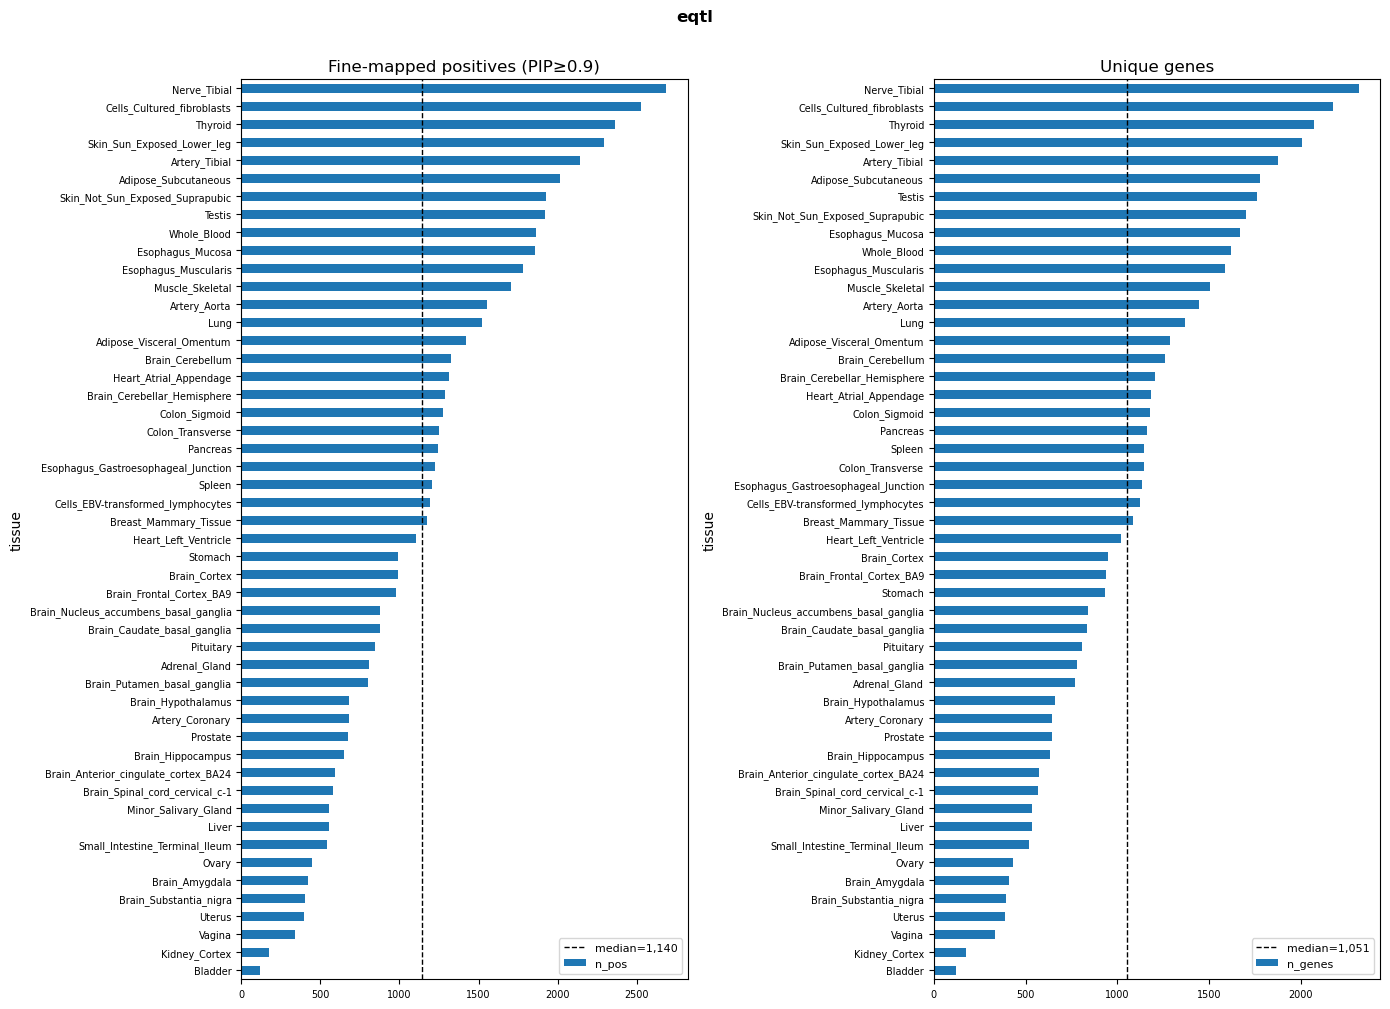

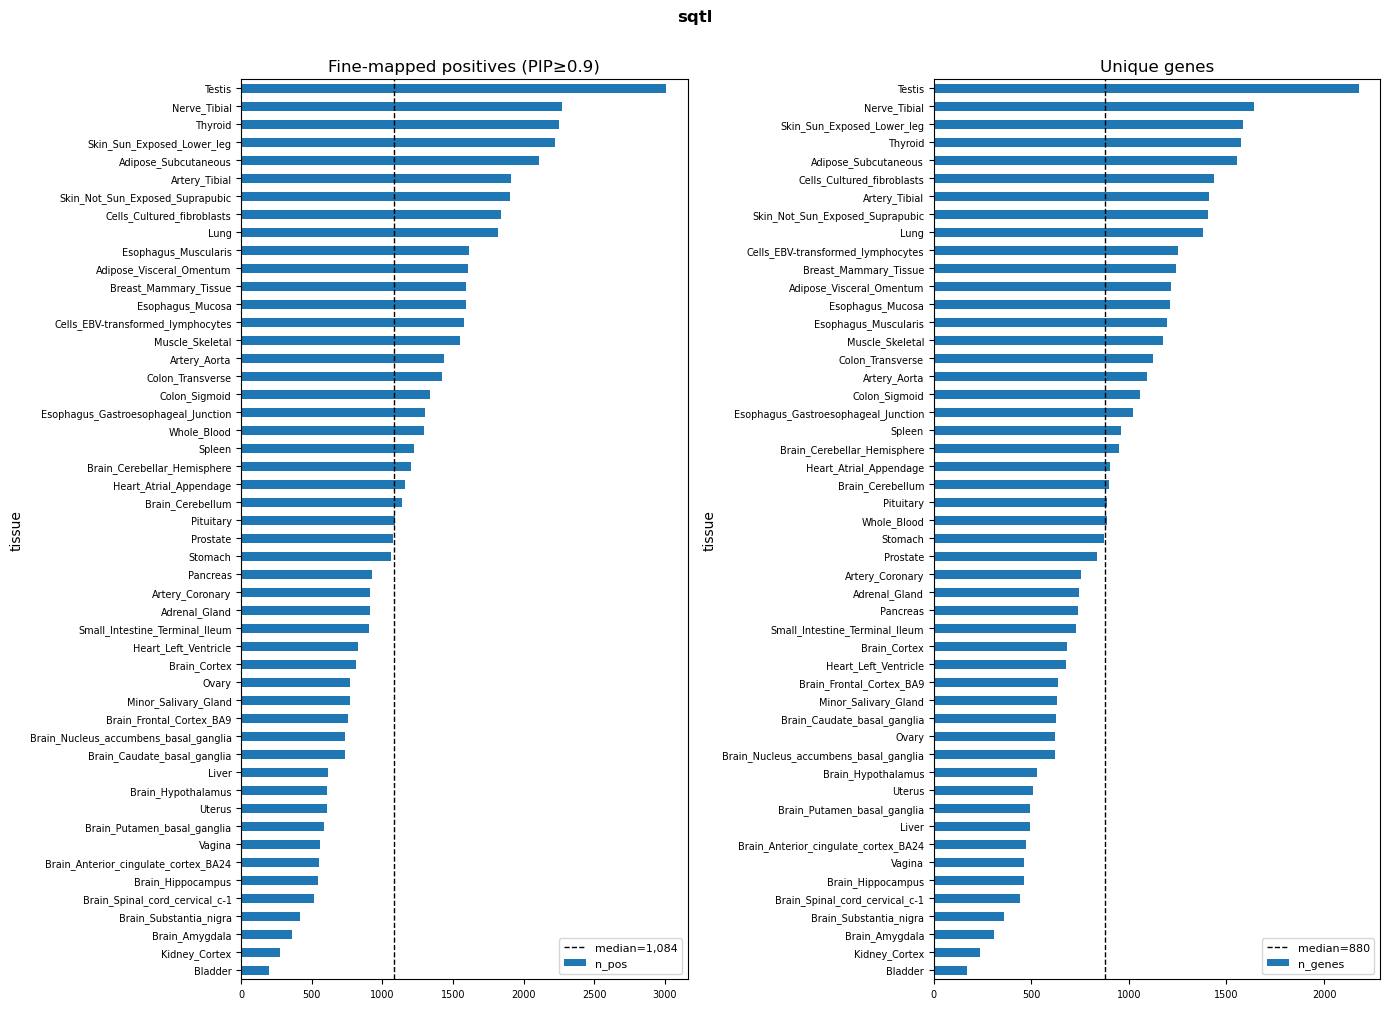

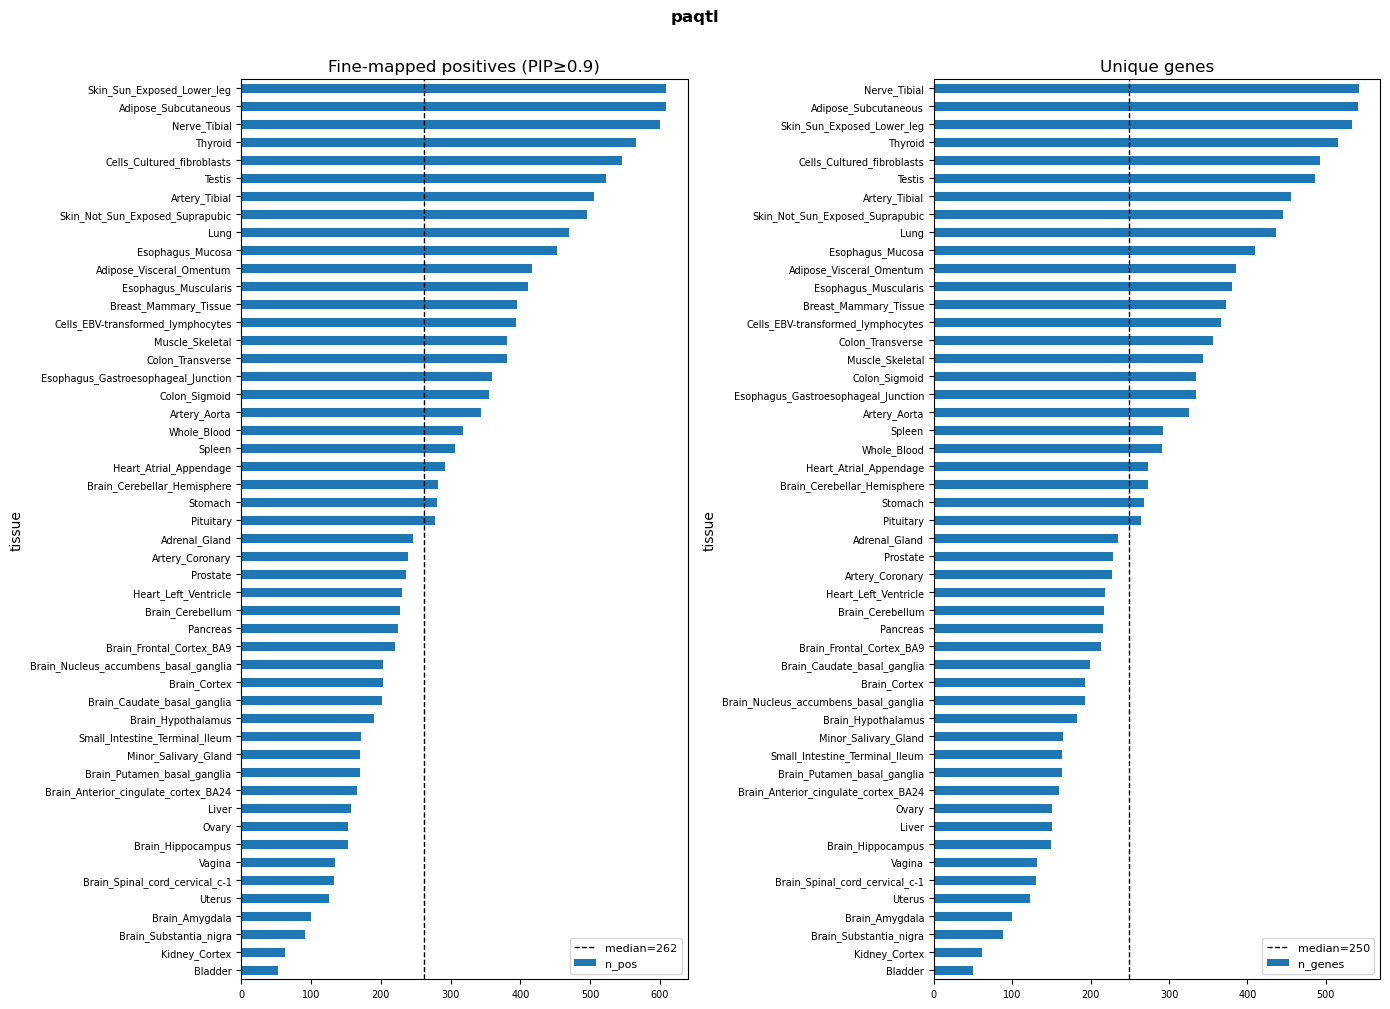

In [5]:
for m in MODS:
    qc_lib.barh_panels(stats[m],
        [("n_pos", f"Fine-mapped positives (PIP≥{PIP_THRESH})"),
         ("n_genes", "Unique genes")], suptitle=m)

## QC 2: minor allele frequency

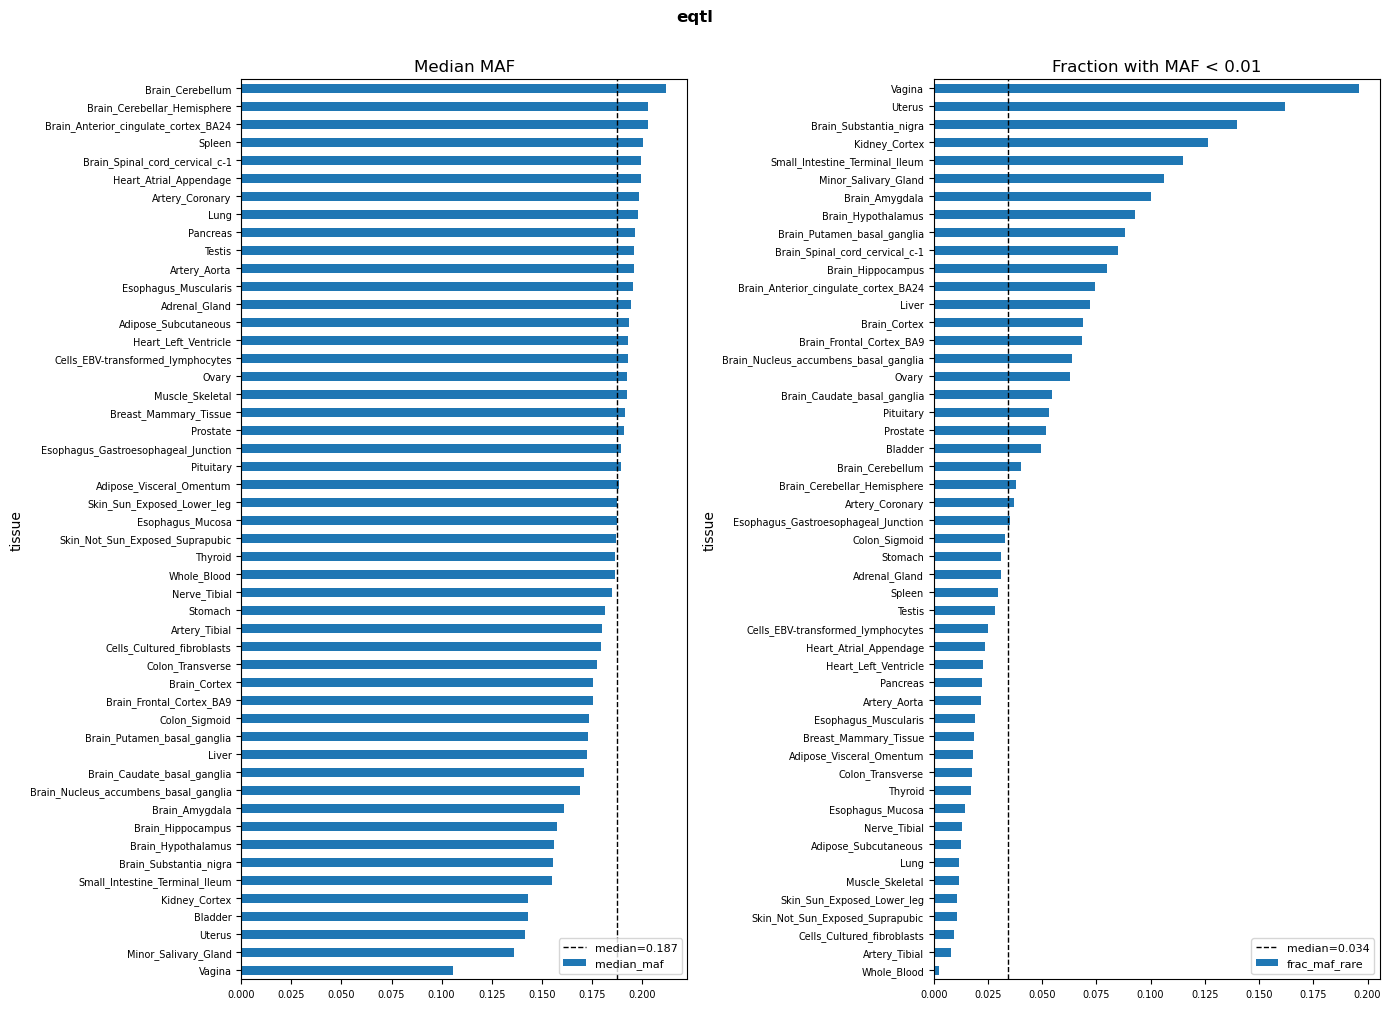

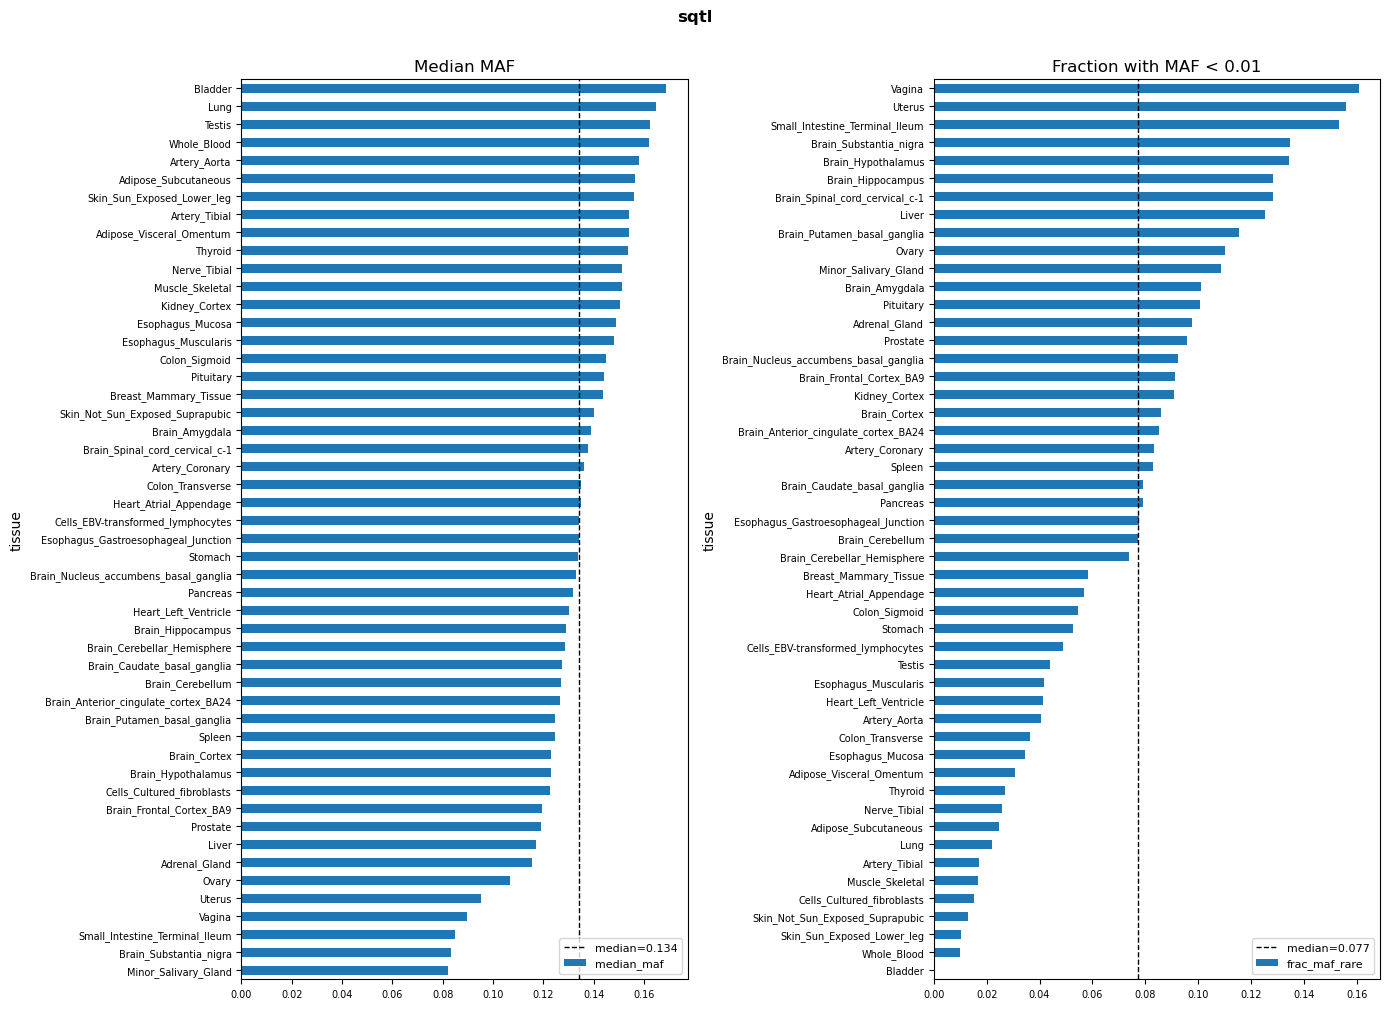

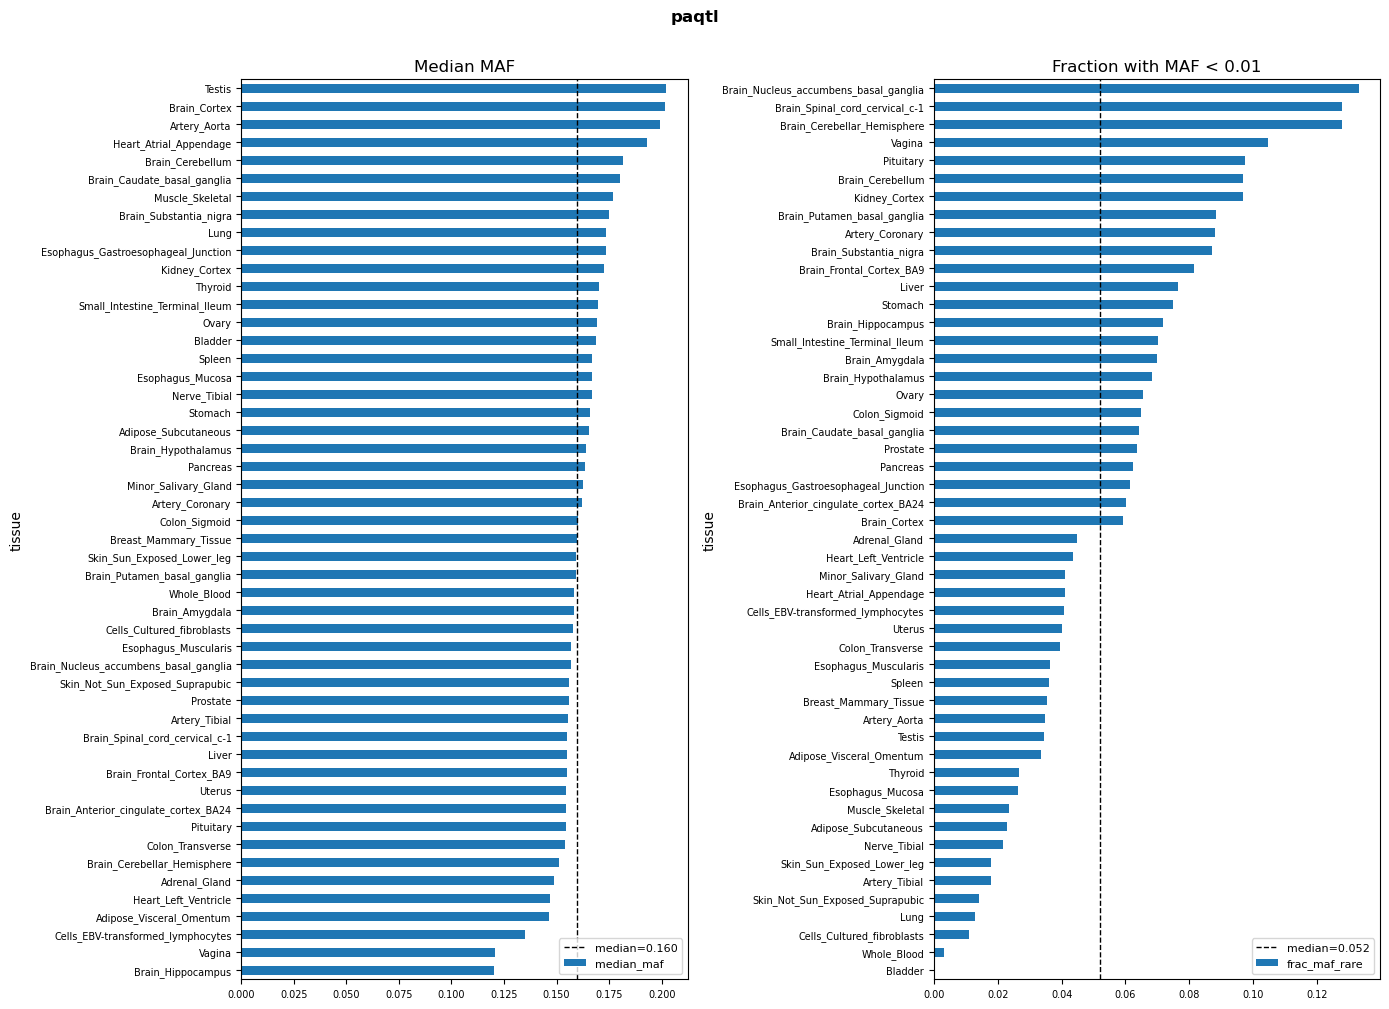

In [6]:
for m in MODS:
    qc_lib.barh_panels(stats[m],
        [("median_maf", "Median MAF"),
         ("frac_maf_rare", f"Fraction with MAF < {MAF_RARE:g}")], suptitle=m)

## QC 3: gene expression level (GTEx median TPM)

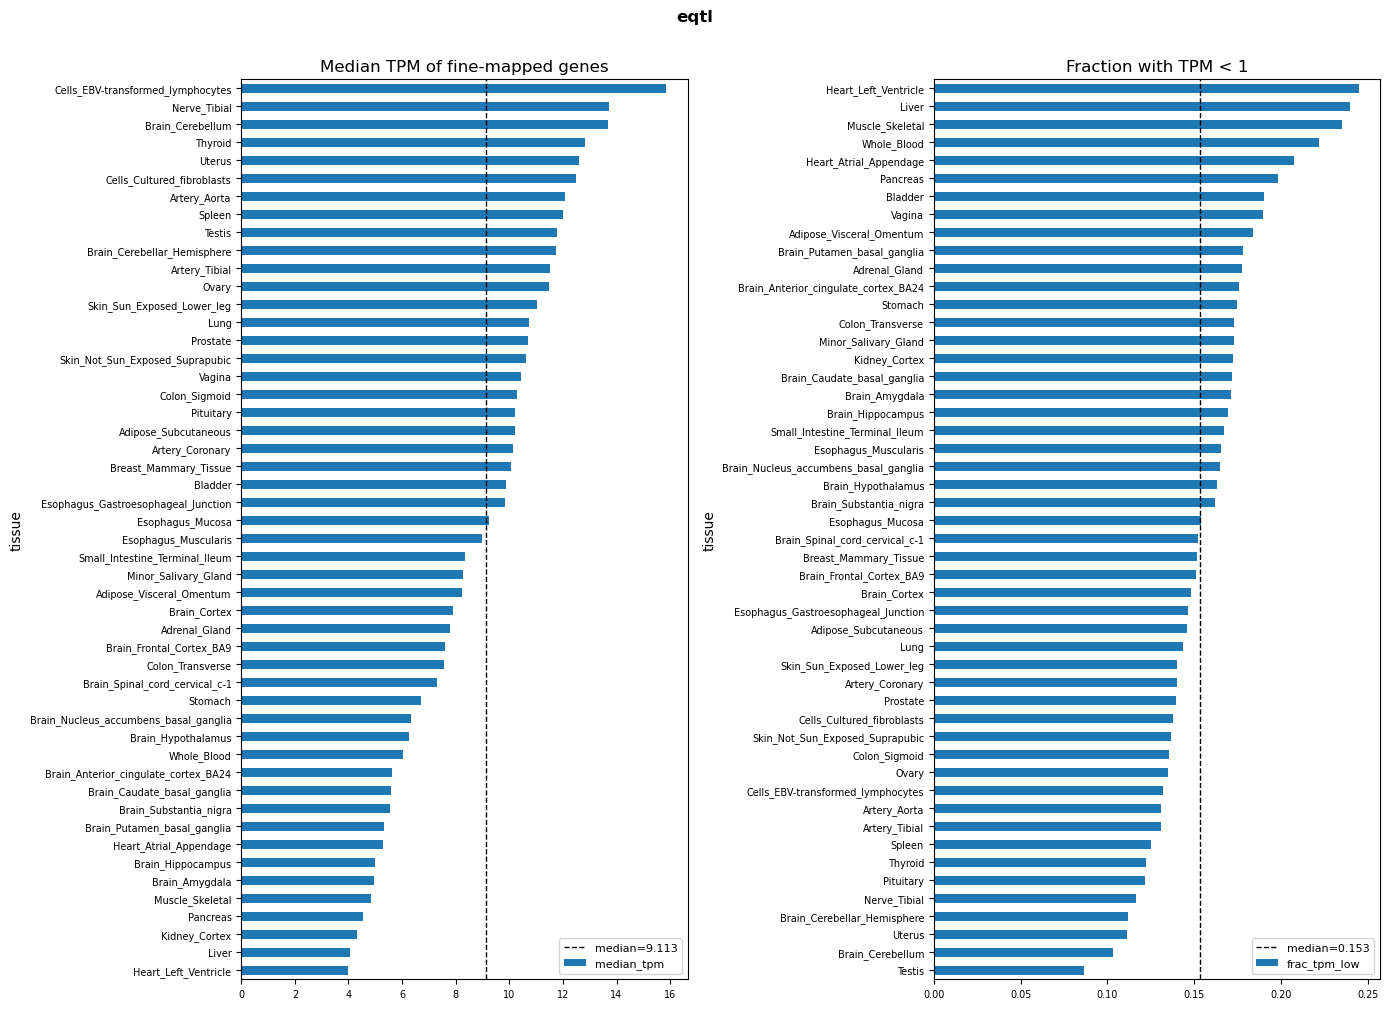

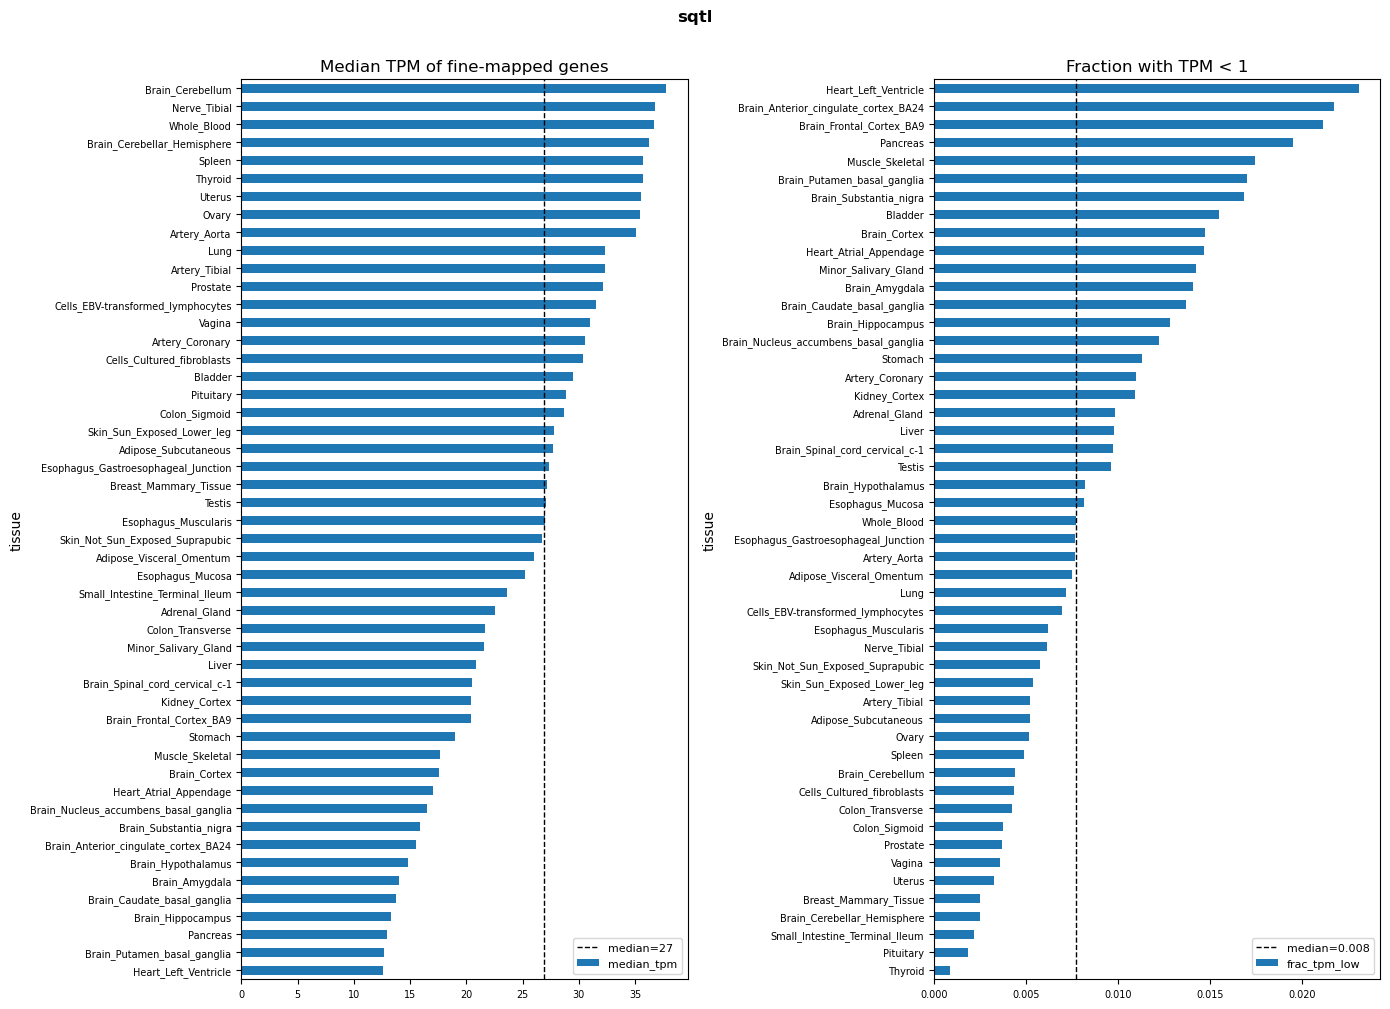

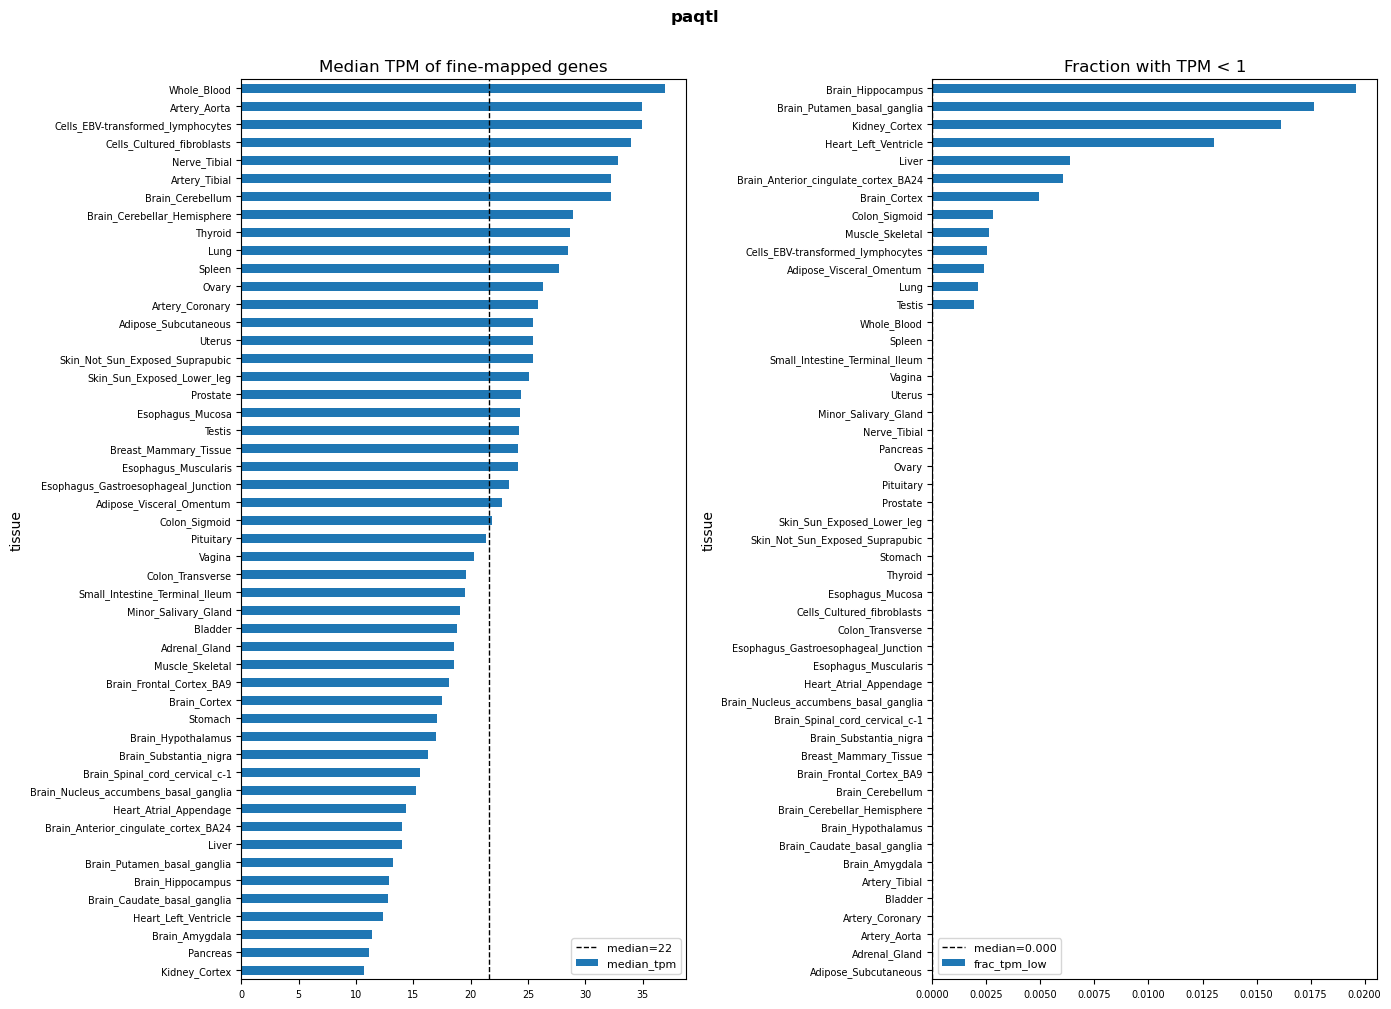

In [7]:
for m in MODS:
    qc_lib.barh_panels(stats[m],
        [("median_tpm", "Median TPM of fine-mapped genes"),
         ("frac_tpm_low", f"Fraction with TPM < {TPM_LOW:g}")], suptitle=m)

## QC 4: distance to the cognate feature

TSS for eQTL, nearest splice site for sQTL, nearest annotated 3′ end for apaQTL —
in every case the minimum over the annotated features of the variant's own gene.

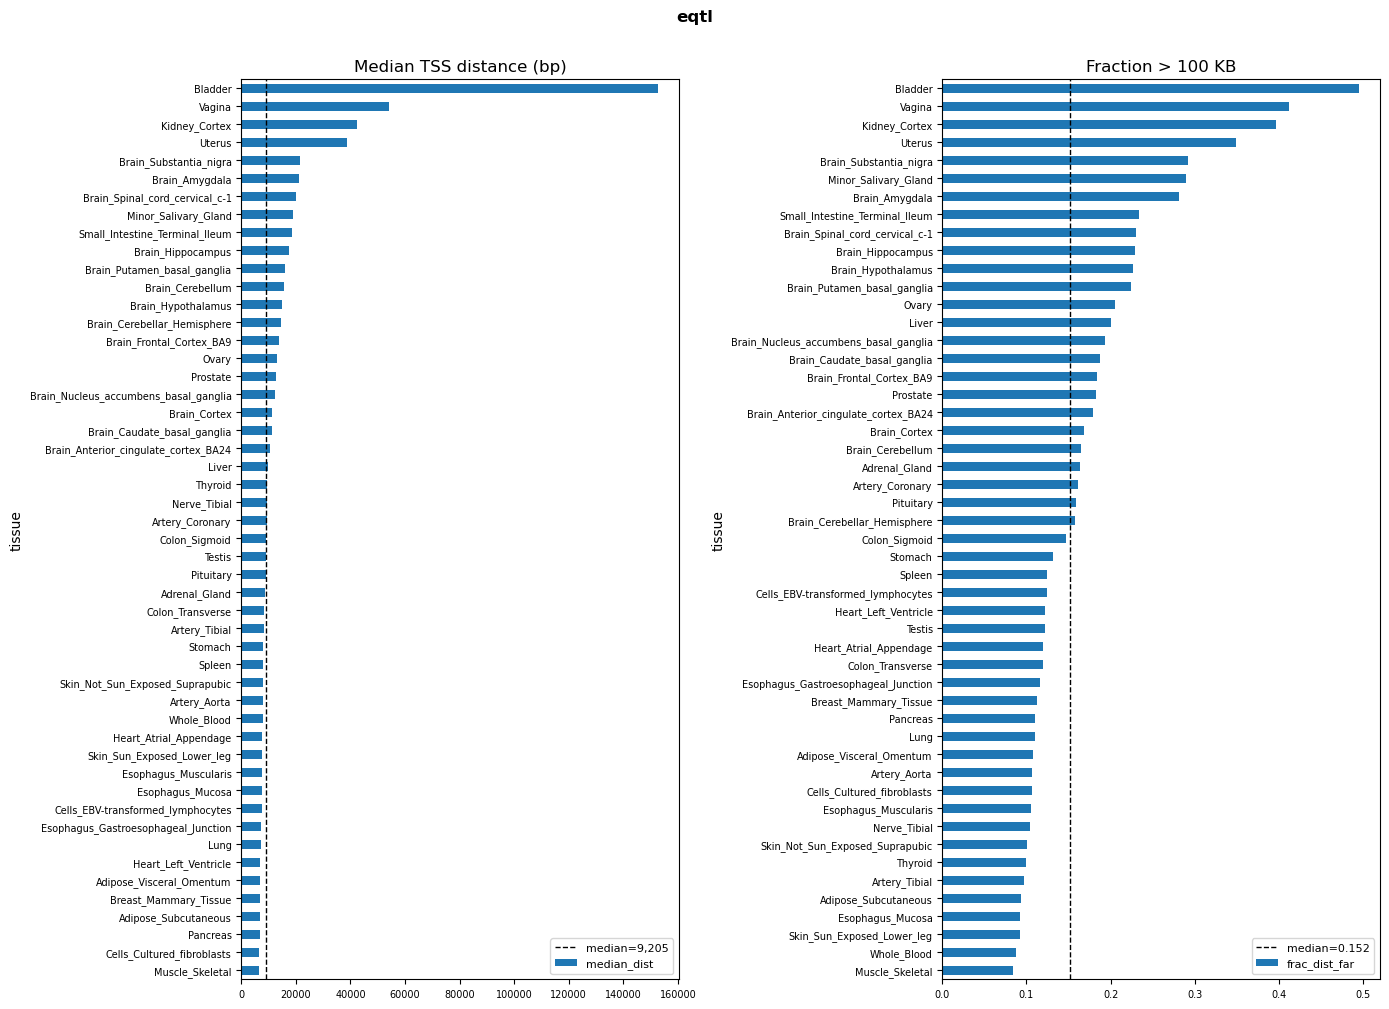

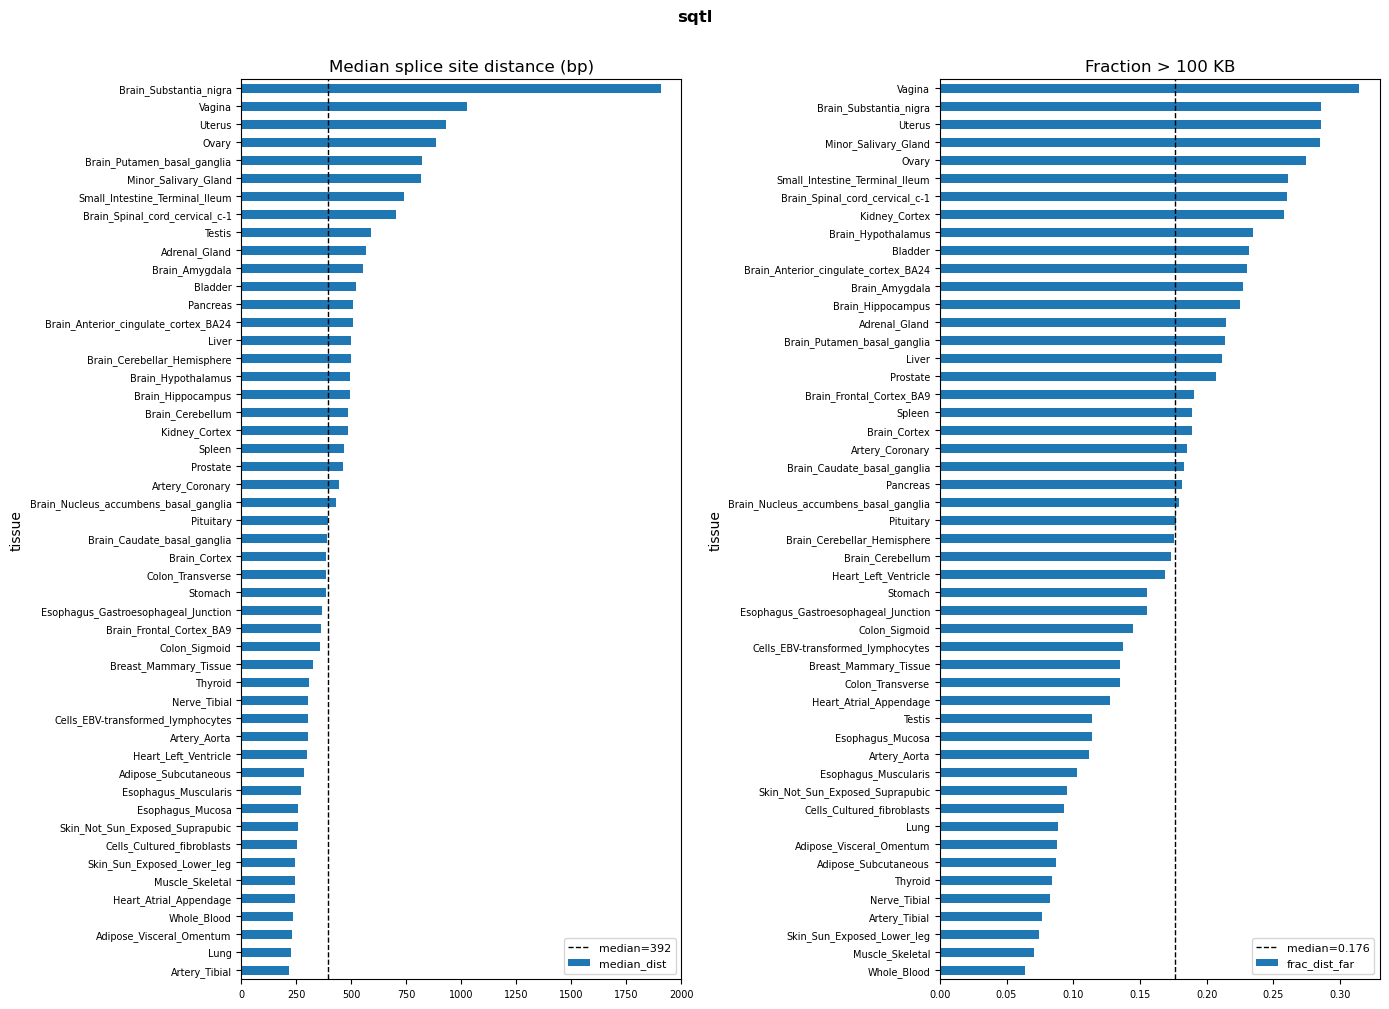

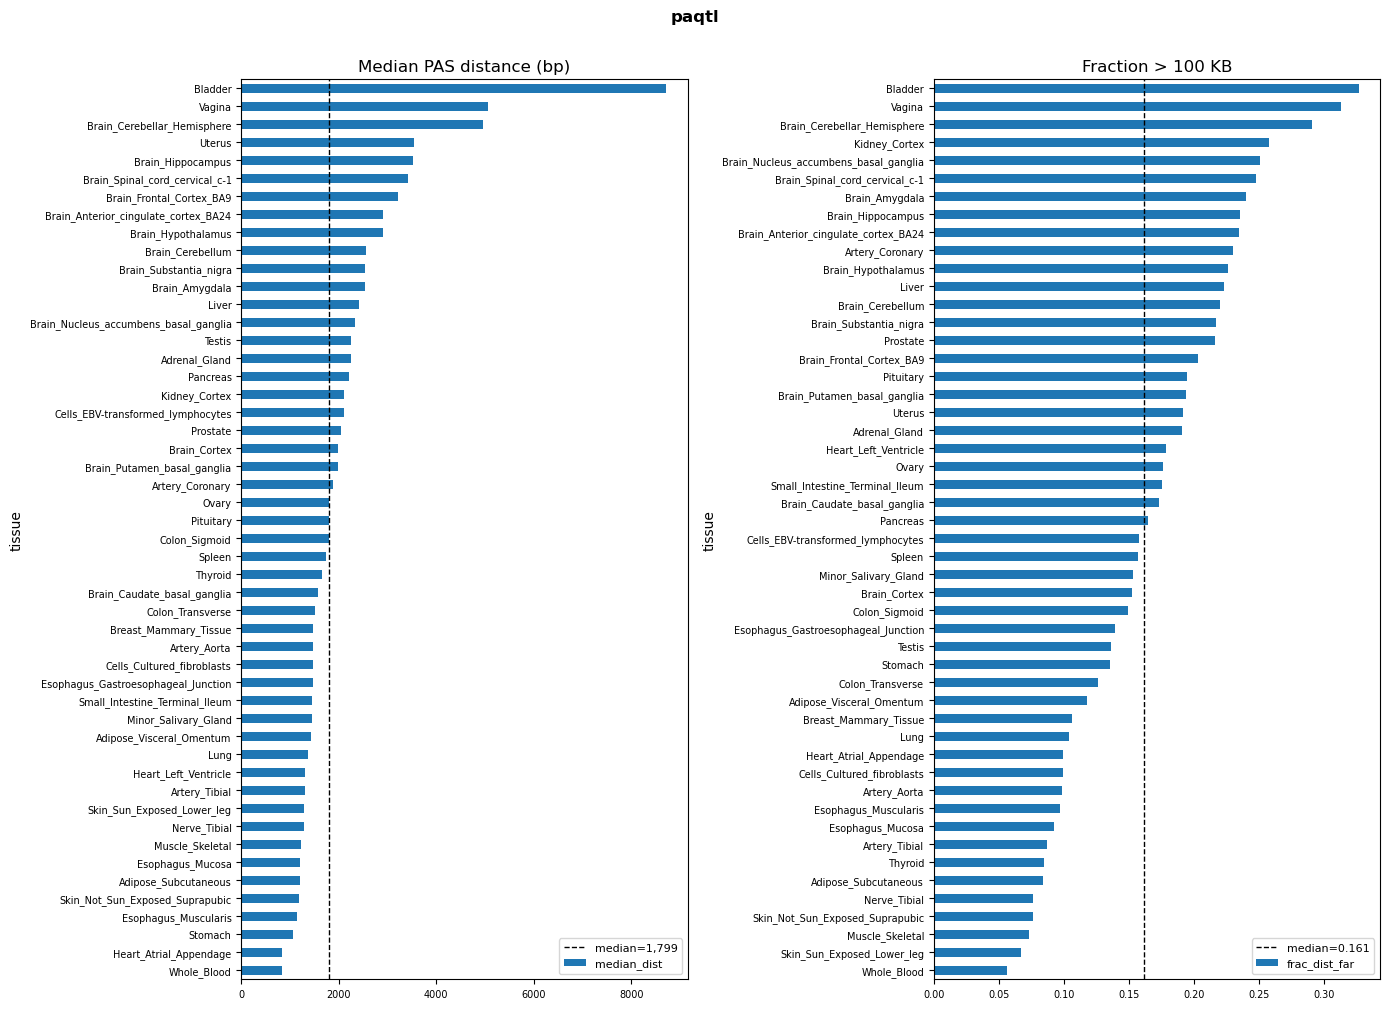

In [8]:
for m in MODS:
    qc_lib.barh_panels(stats[m],
        [("median_dist", f"Median {qc_lib.DIST_LABEL[m]} (bp)"),
         ("frac_dist_far", f"Fraction > {DIST_FAR // 1000} KB")], suptitle=m)

## QC 5: feature distance CDF overlay

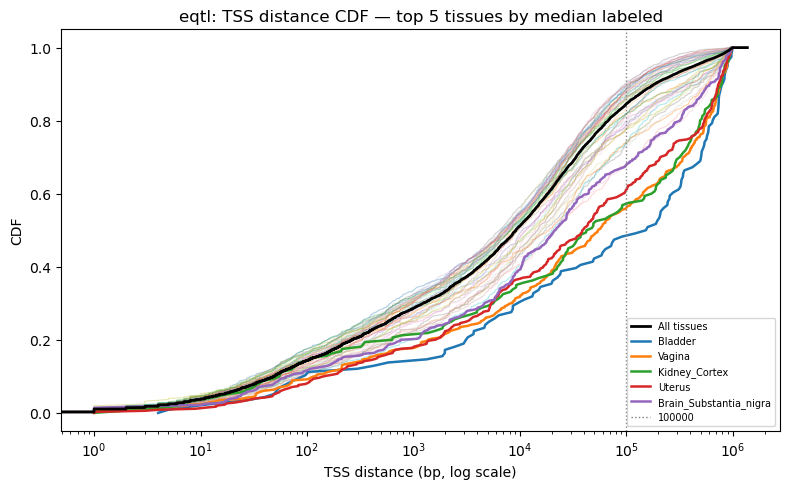

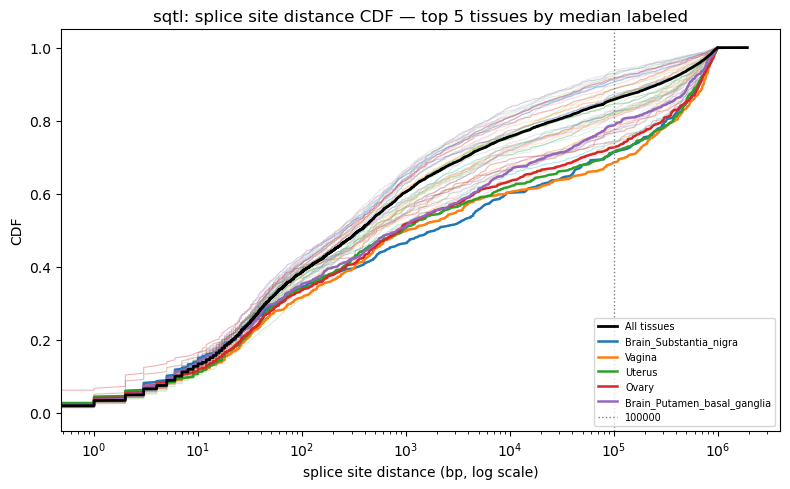

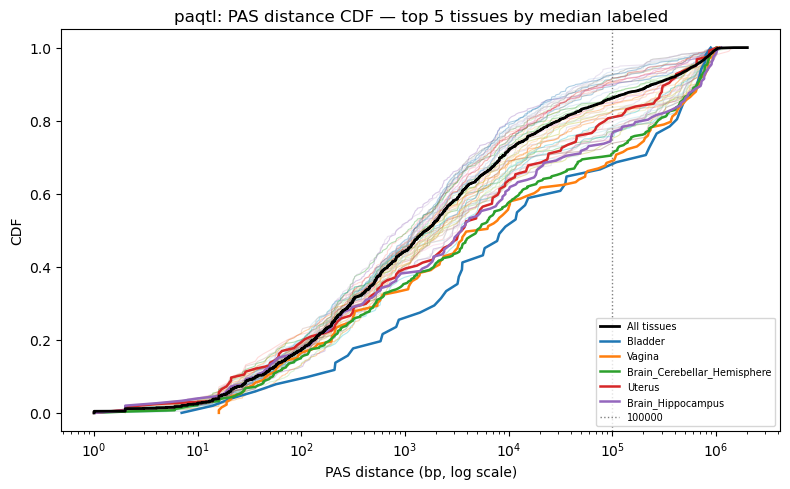

In [9]:
for m in MODS:
    qc_lib.cdf_overlay(pos[m], "dist",
        highlight=stats[m].nlargest(5, "median_dist").index,
        xlabel=f"{qc_lib.DIST_LABEL[m]} (bp, log scale)",
        title=f"{m}: {qc_lib.DIST_LABEL[m]} CDF — top 5 tissues by median labeled",
        vline=DIST_FAR)

## QC 6: effect size and fine-mapping confidence

Effect size is |AFC| (log2 allelic fold change) for eQTL and |slope| (per-allele
change in usage ratio) for sQTL and apaQTL.

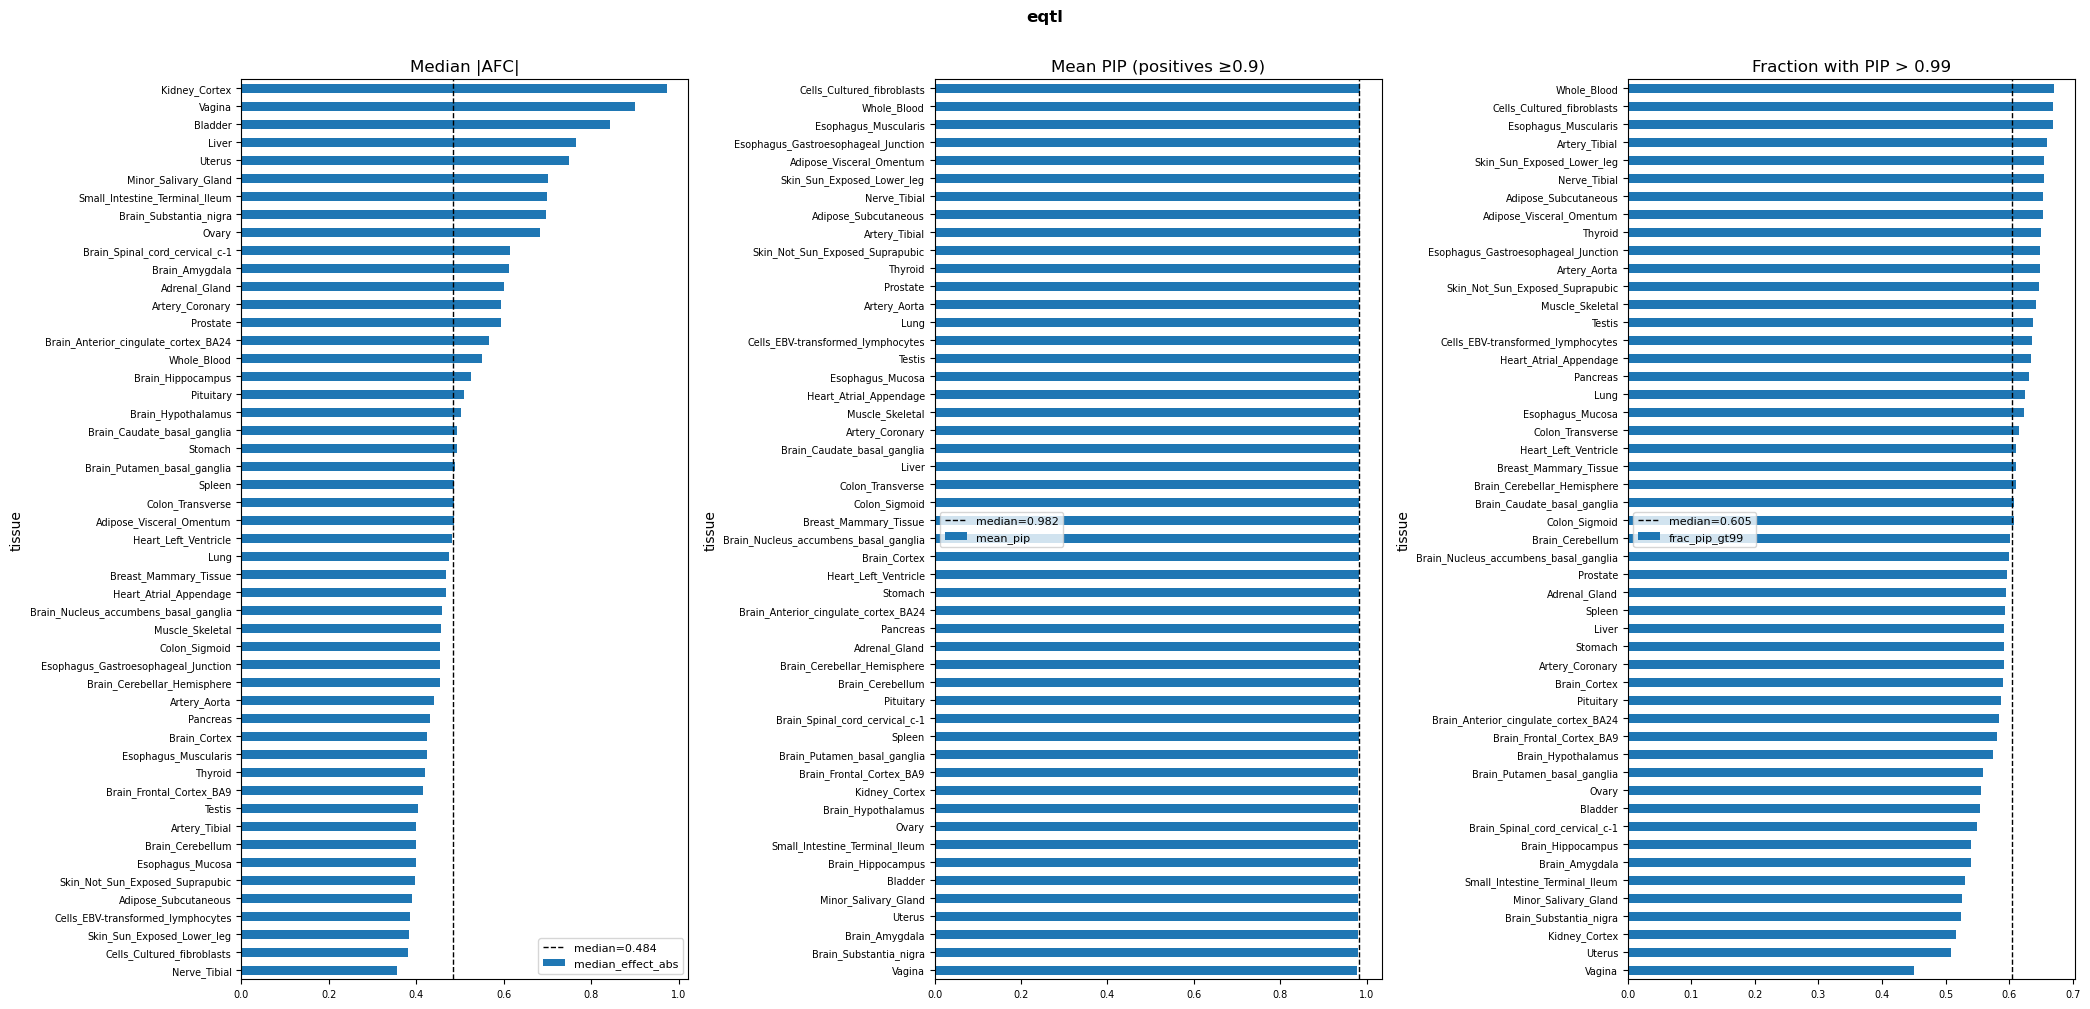

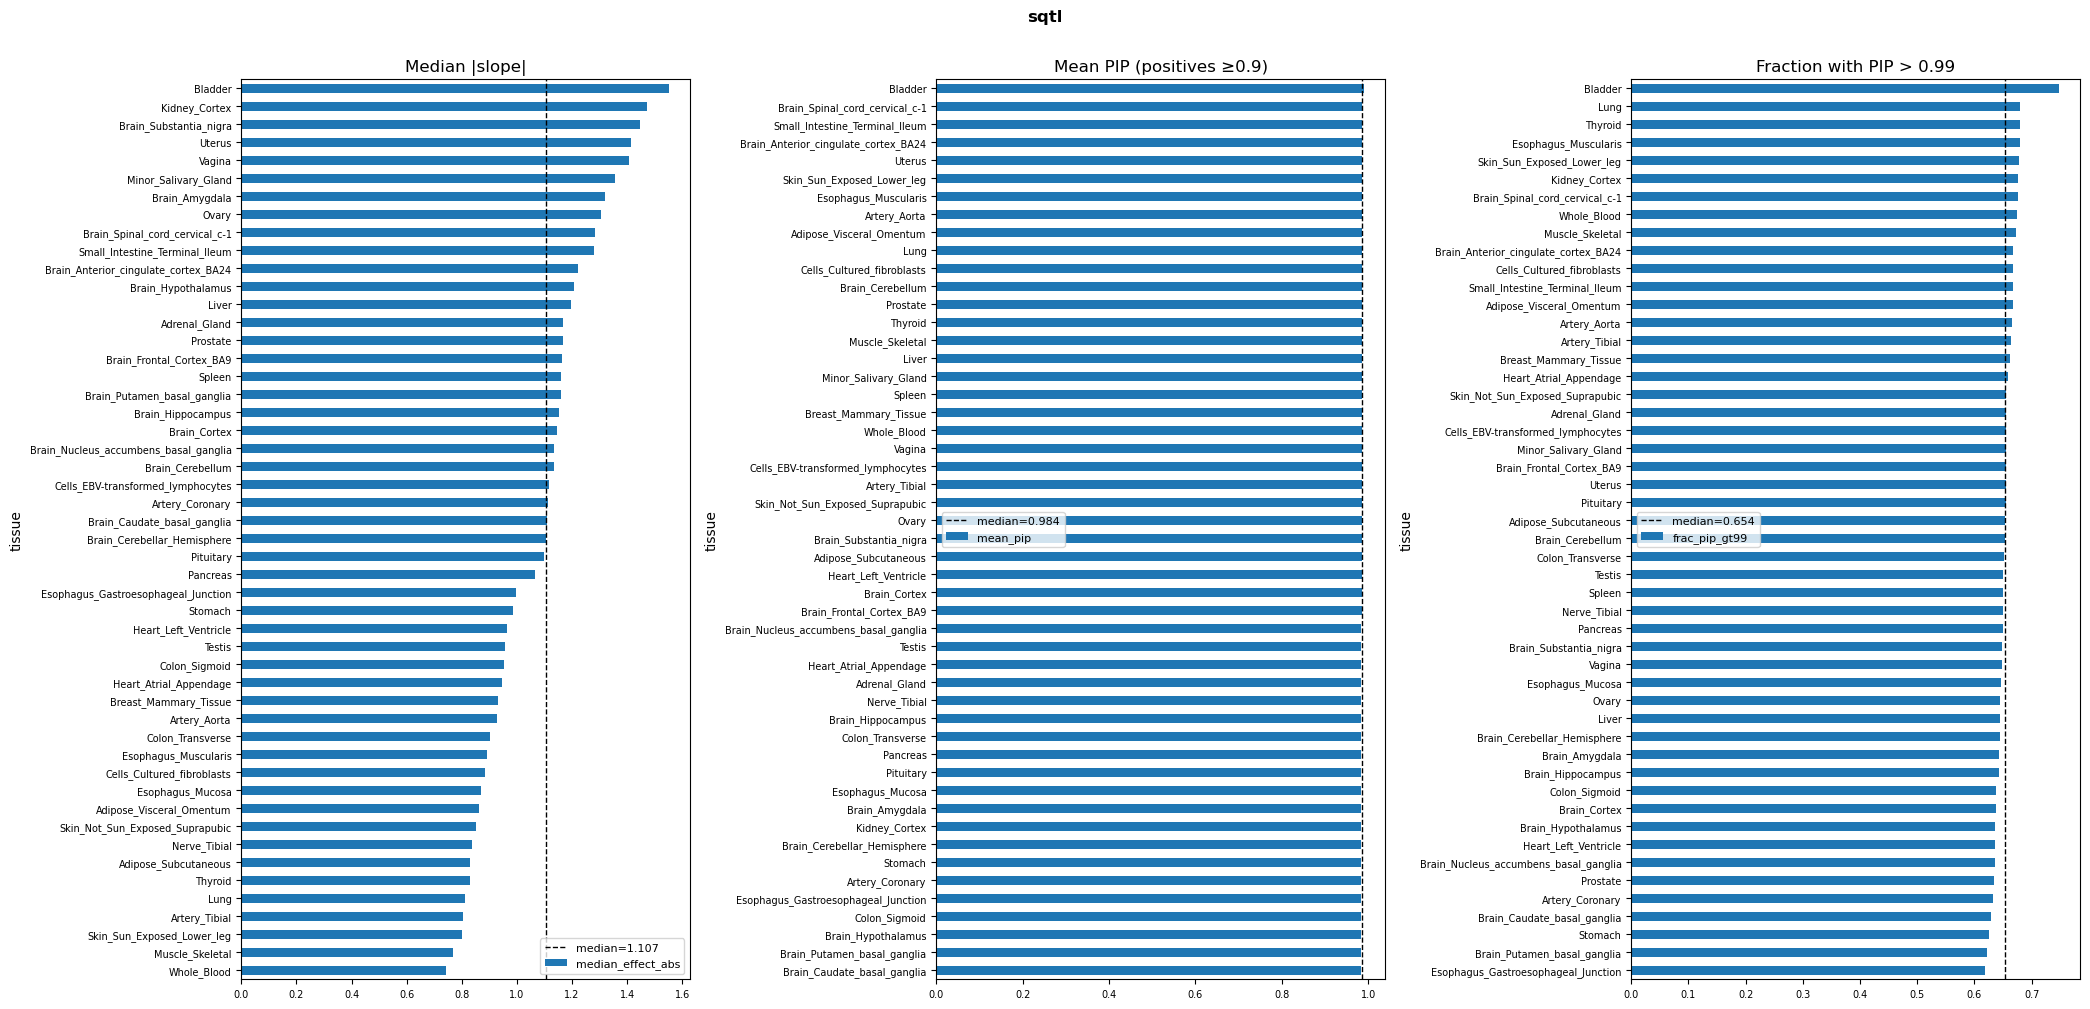

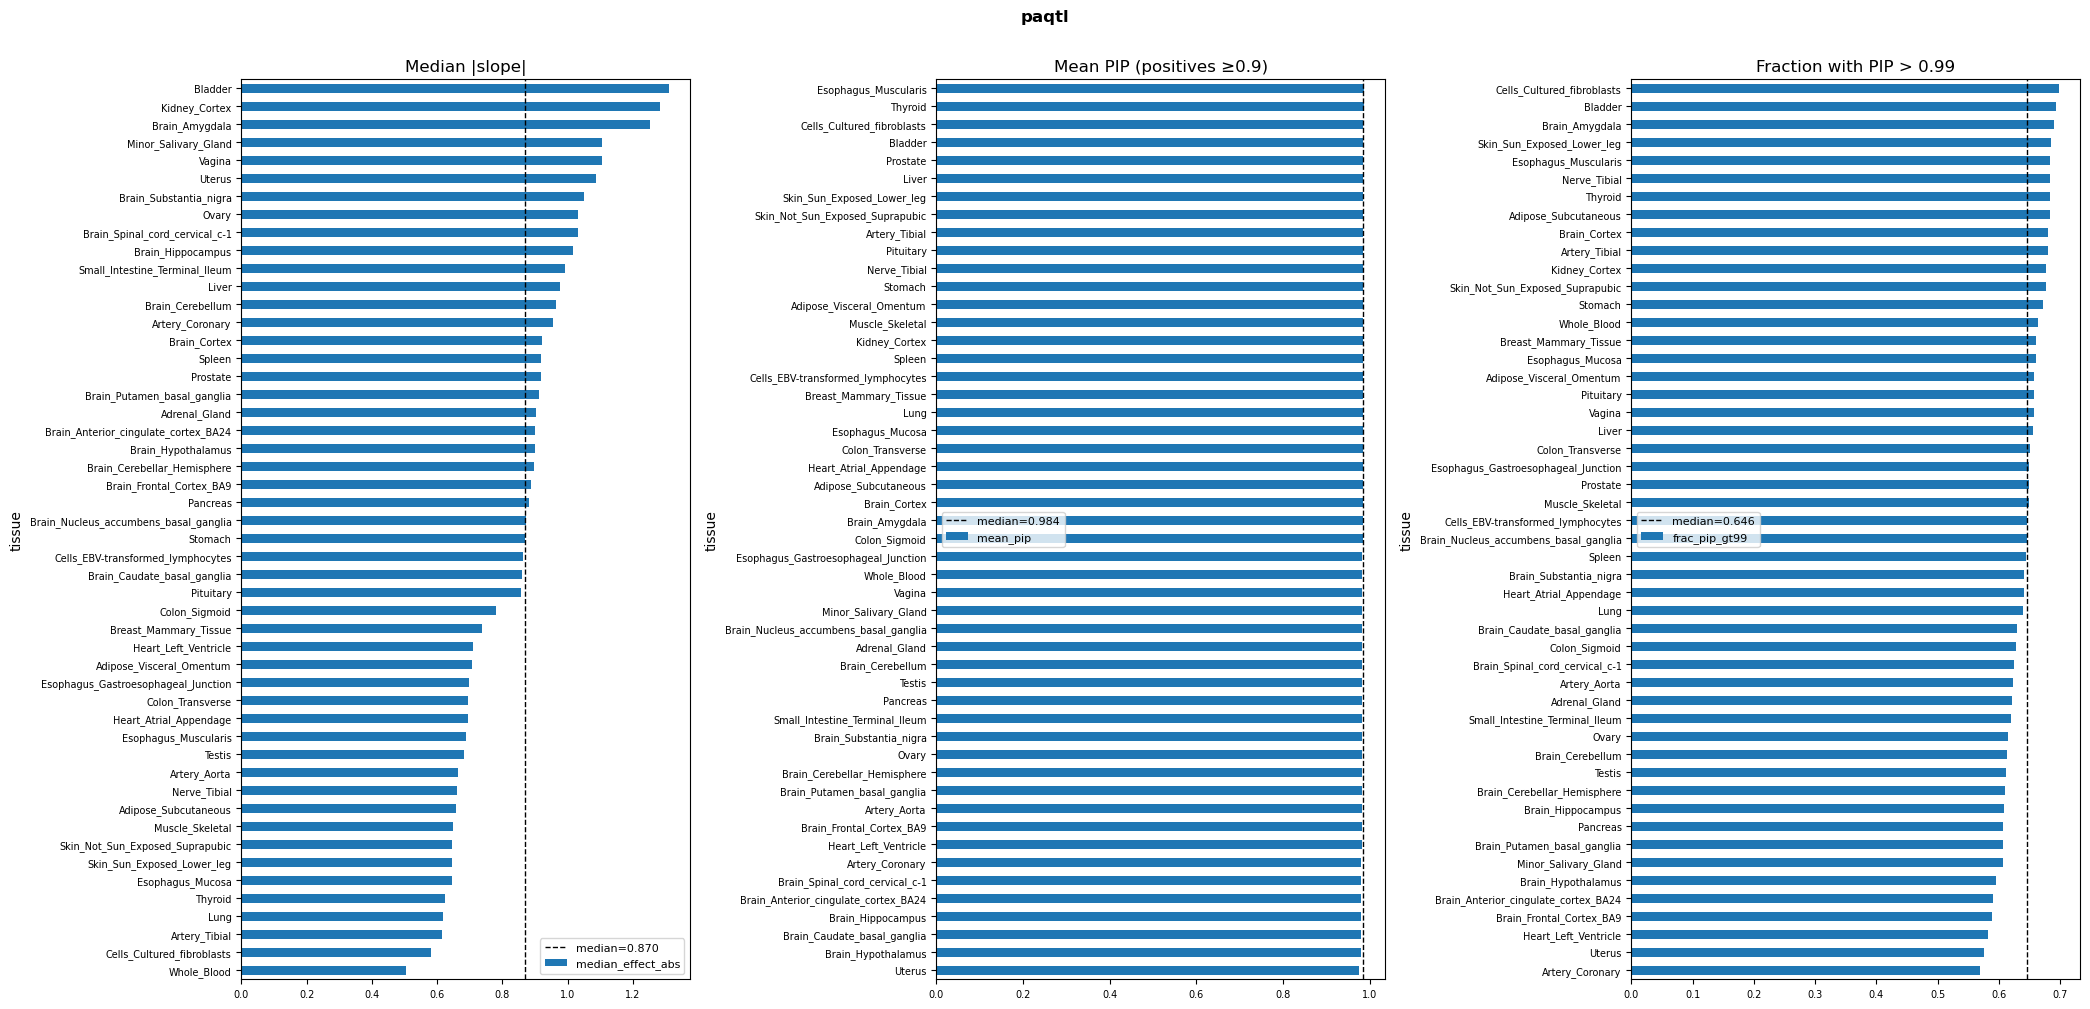

In [10]:
for m in MODS:
    qc_lib.barh_panels(stats[m],
        [("median_effect_abs", f"Median {qc_lib.EFFECT_LABEL[m]}"),
         ("mean_pip", f"Mean PIP (positives ≥{PIP_THRESH})"),
         ("frac_pip_gt99", "Fraction with PIP > 0.99")], suptitle=m)

## QC 7: nominal association strength (NLP = −log10 p)

A QQ plot is uninformative here because positives are pre-selected at high PIP.
Per-tissue medians and CDFs instead flag tissues whose fine-mapped variants rest on
unusually weak underlying associations.

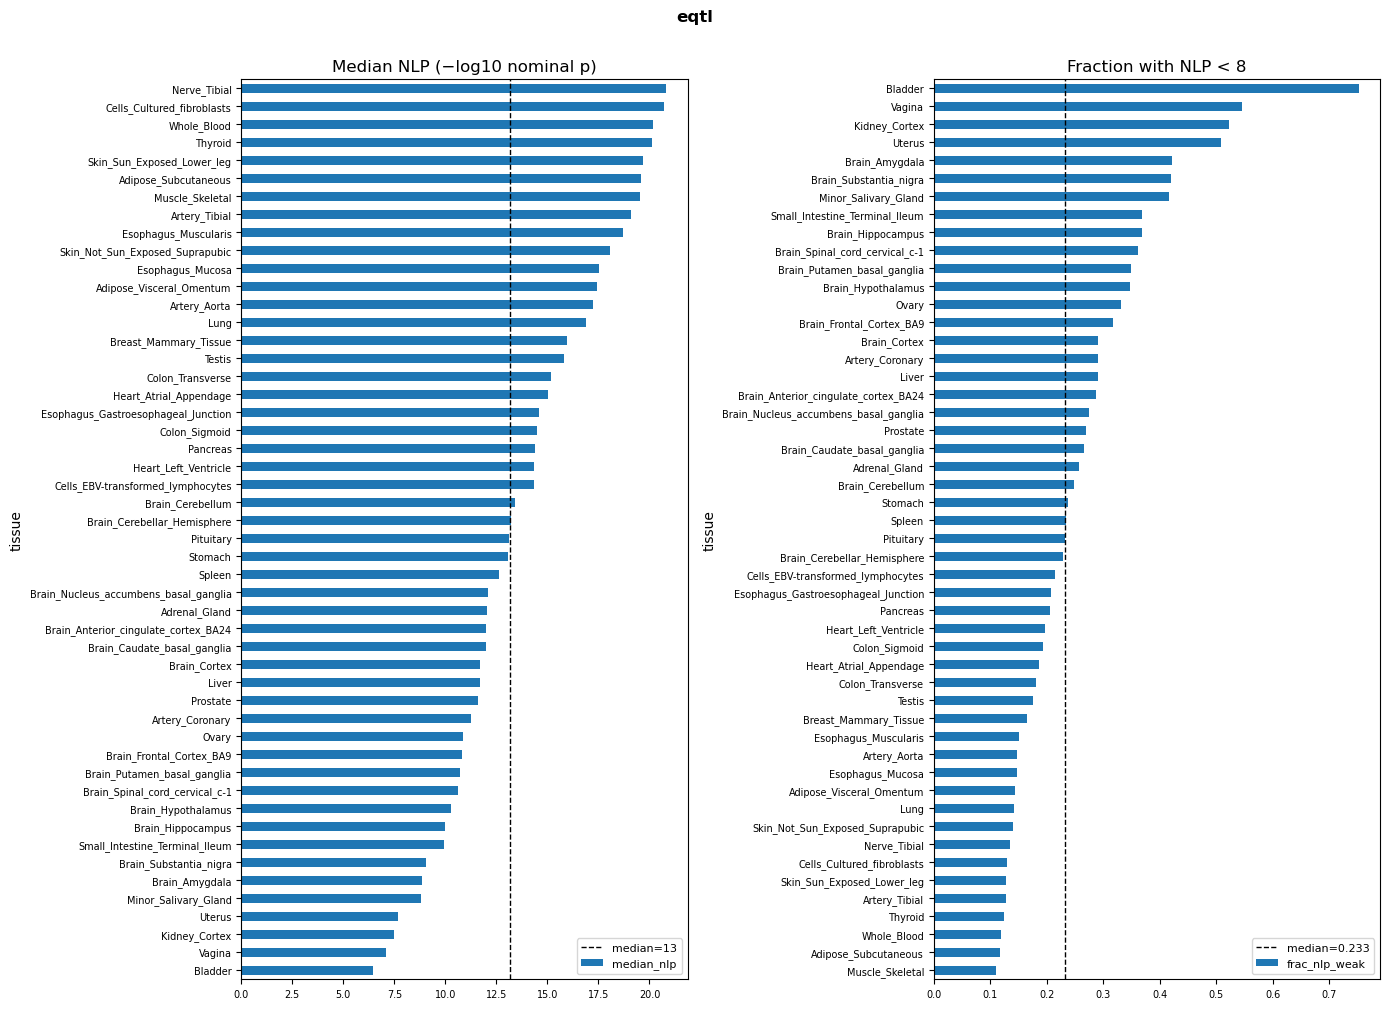

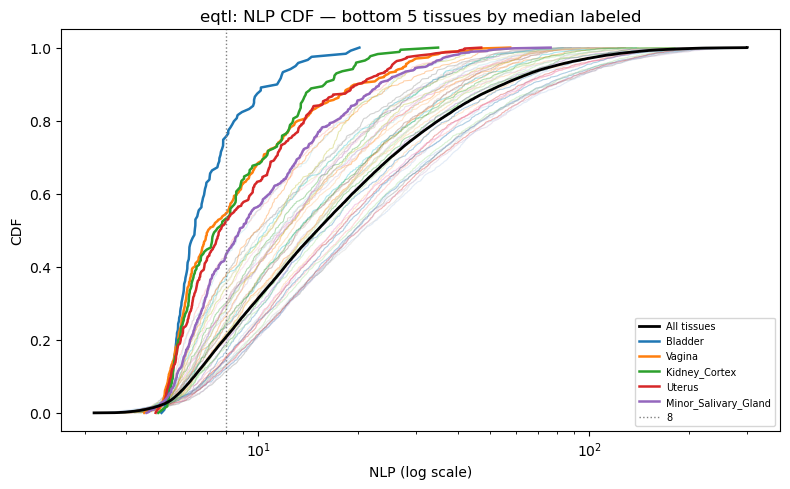

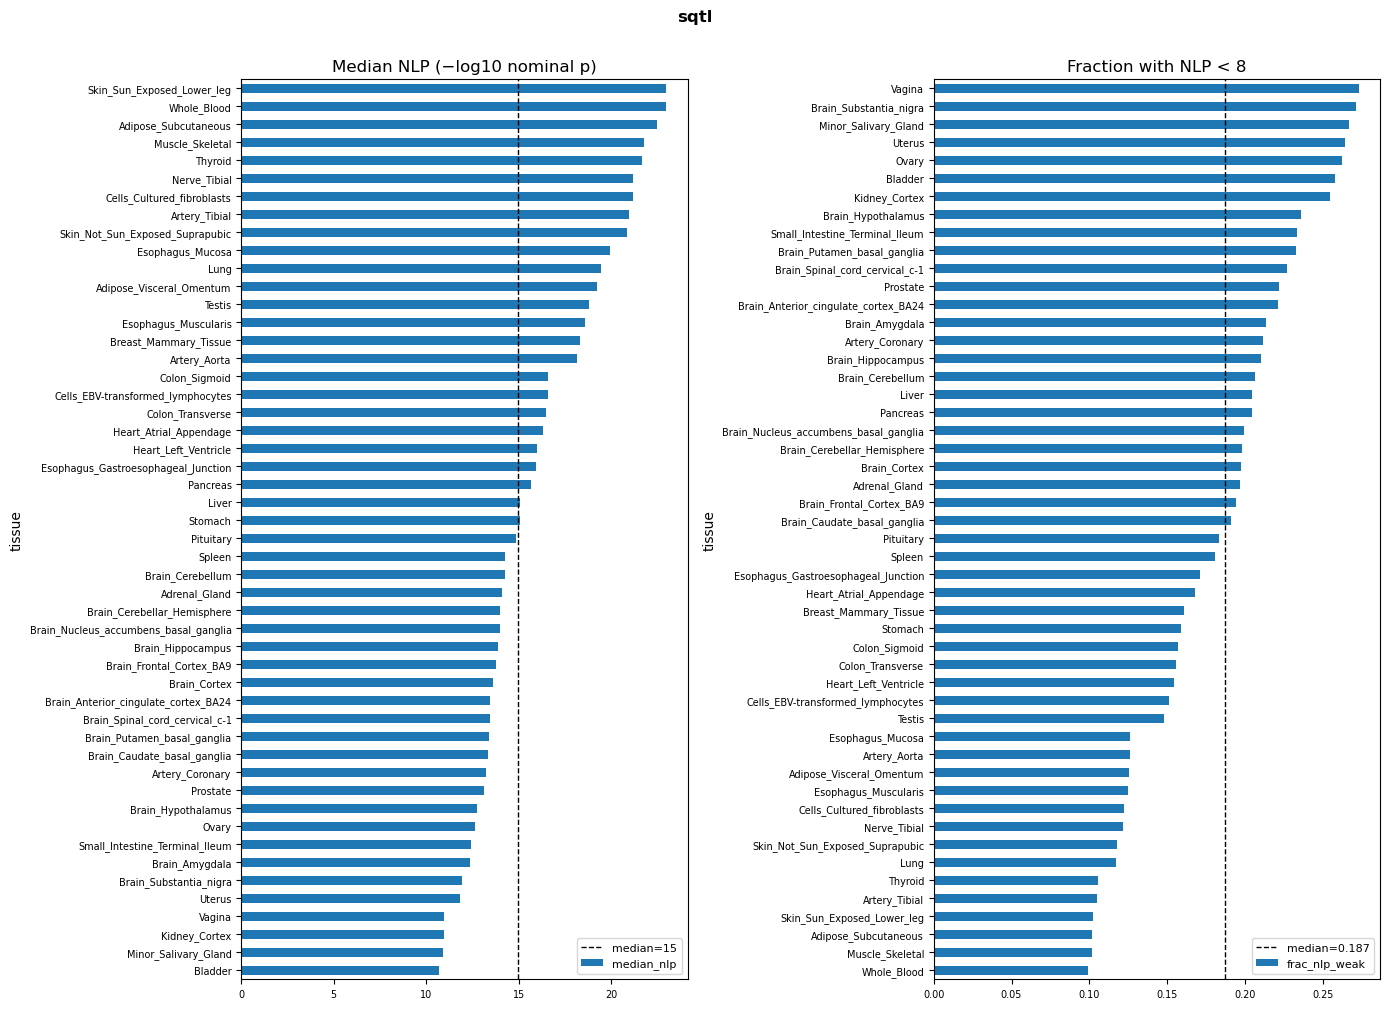

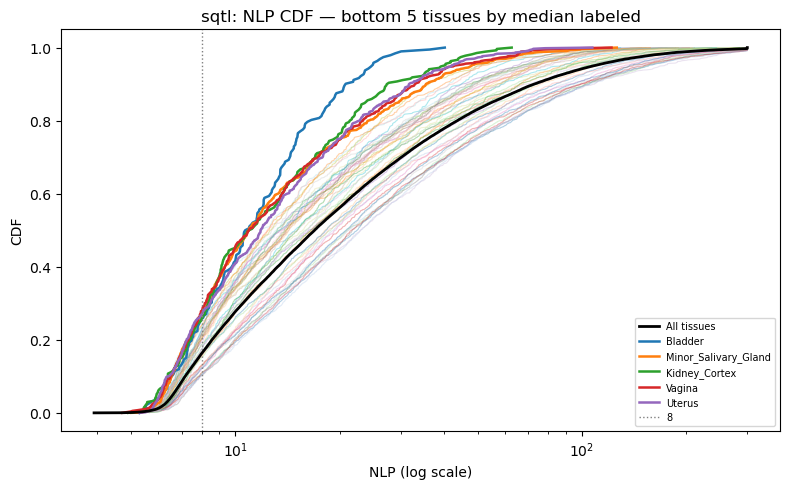

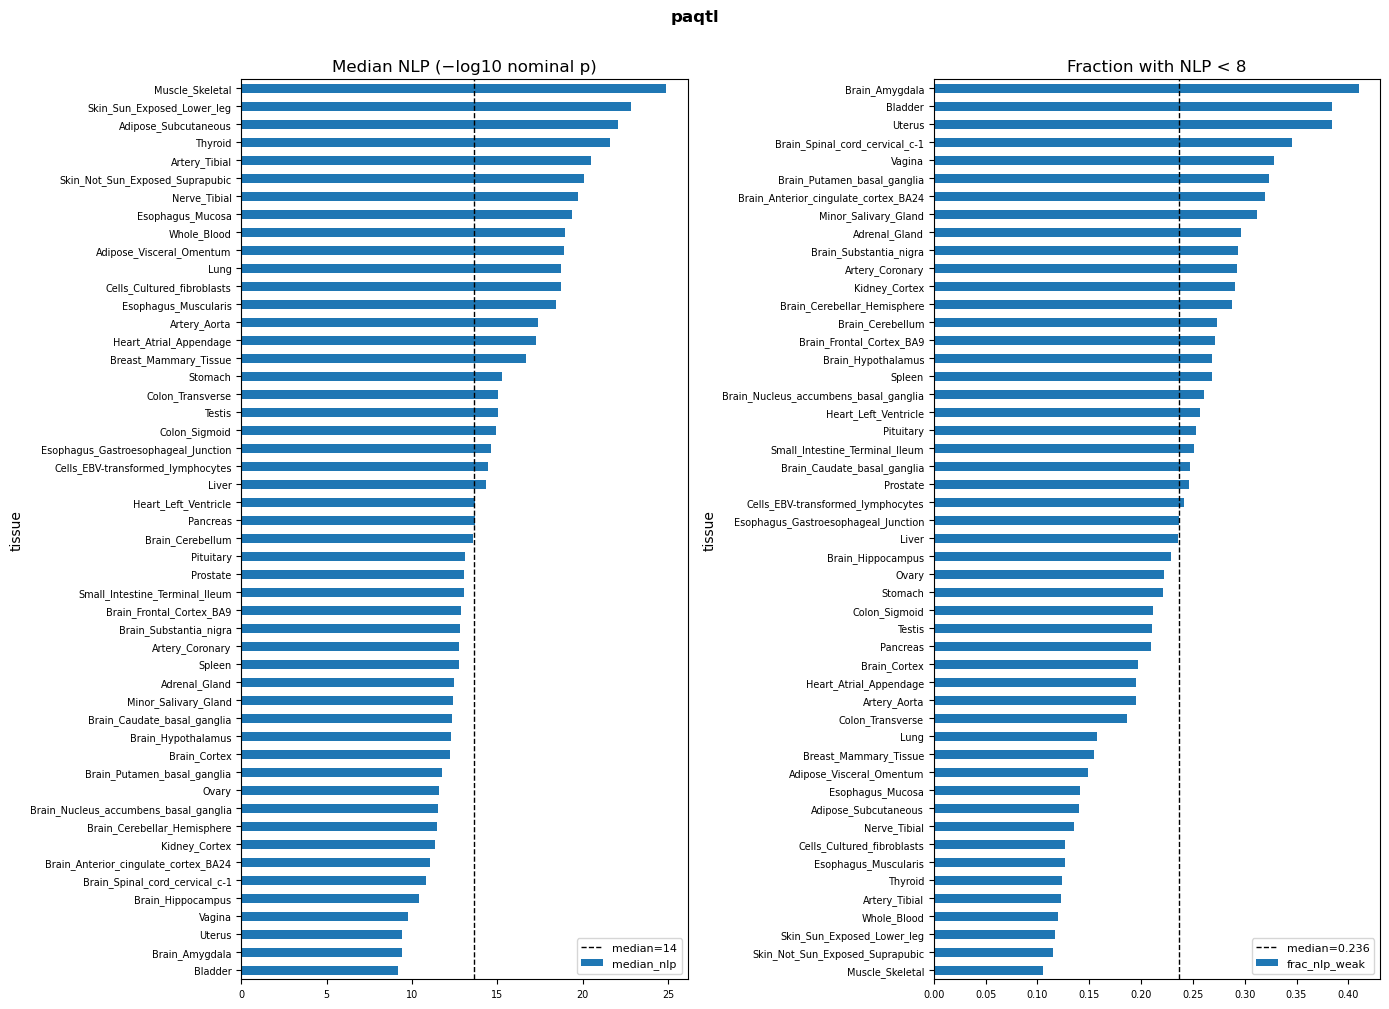

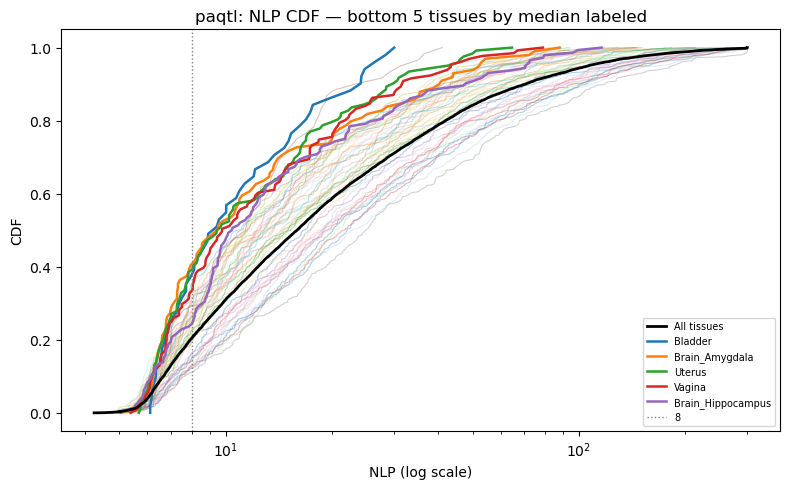

In [11]:
for m in MODS:
    qc_lib.barh_panels(stats[m],
        [("median_nlp", "Median NLP (−log10 nominal p)"),
         ("frac_nlp_weak", f"Fraction with NLP < {NLP_WEAK:g}")], suptitle=m)
    qc_lib.cdf_overlay(pos[m], "nlp",
        highlight=stats[m].nsmallest(5, "median_nlp").index,
        xlabel="NLP (log scale)",
        title=f"{m}: NLP CDF — bottom 5 tissues by median labeled",
        vline=NLP_WEAK)

## QC 8: eQTL region annotation

eQTL positives alone carry a region label, assigned by `eqtl_vcfs.classify_region`
relative to the eQTL gene (canonical-transcript tie-break; UTR3 takes precedence).
Per-tissue composition flags unusually skewed tissues; the pooled per-region
marginals confirm the three compartments behave qualitatively differently, which is
why they are matched separately.

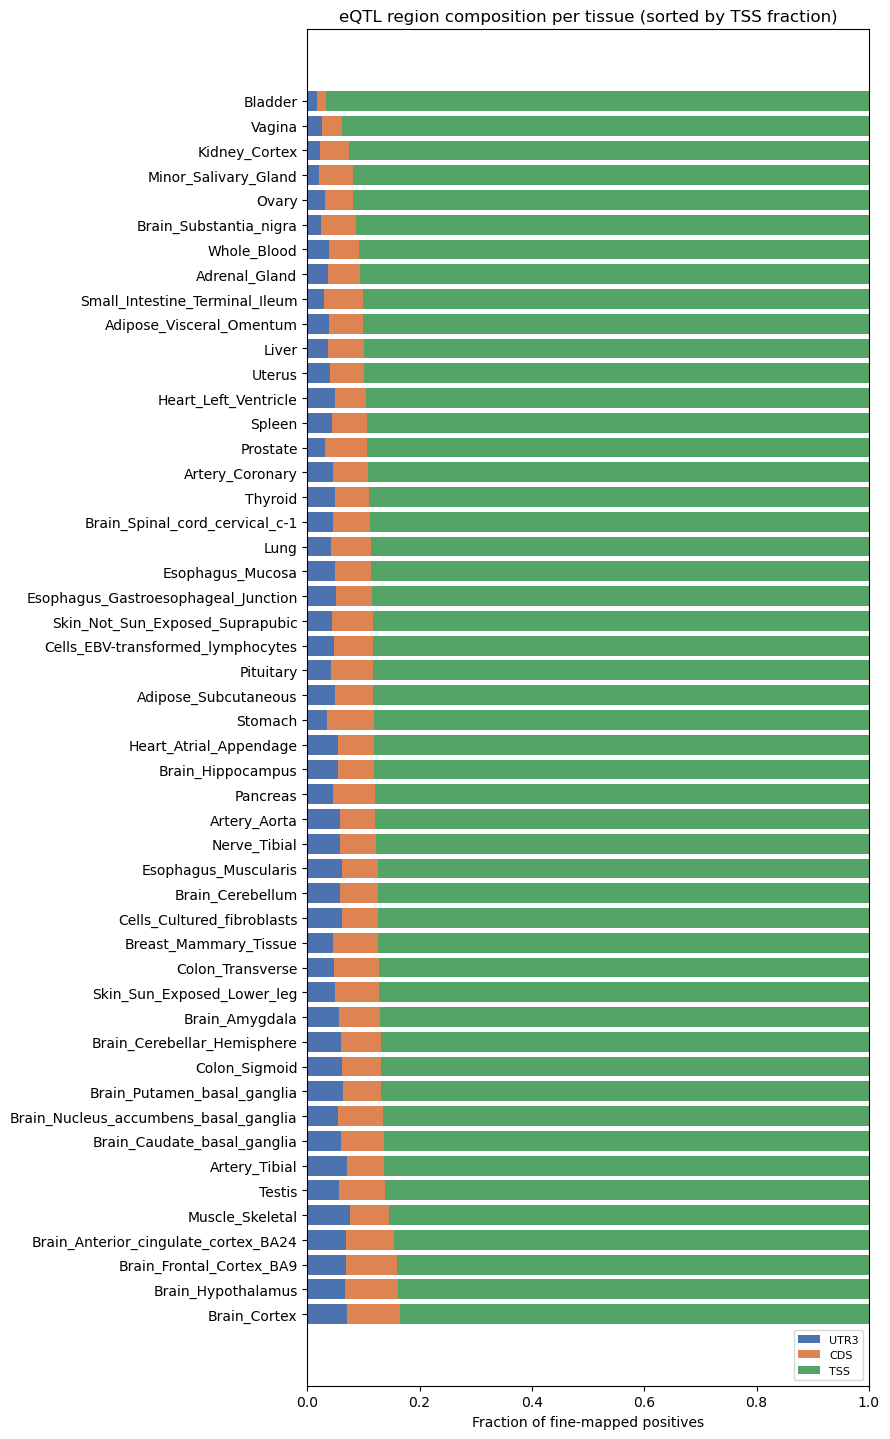

Pooled region counts:
region
TSS     51121
CDS      3989
UTR3     3012


In [12]:
REGION_ORDER  = ["UTR3", "CDS", "TSS"]
REGION_COLORS = {"UTR3": "#4c72b0", "CDS": "#dd8452", "TSS": "#55a467"}

p = pos["eqtl"]
region_frac = (pd.crosstab(p.tissue, p.region, normalize="index")
               .reindex(columns=REGION_ORDER, fill_value=0).sort_values("TSS"))

fig, ax = plt.subplots(figsize=(9, len(region_frac) * 0.27 + 1))
left = np.zeros(len(region_frac))
for r in REGION_ORDER:
    ax.barh(region_frac.index, region_frac[r].values, left=left,
            color=REGION_COLORS[r], label=r)
    left = left + region_frac[r].values
ax.set_xlim(0, 1)
ax.set_xlabel("Fraction of fine-mapped positives")
ax.set_title("eQTL region composition per tissue (sorted by TSS fraction)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

print("Pooled region counts:")
print(p.region.value_counts(dropna=False).to_string())

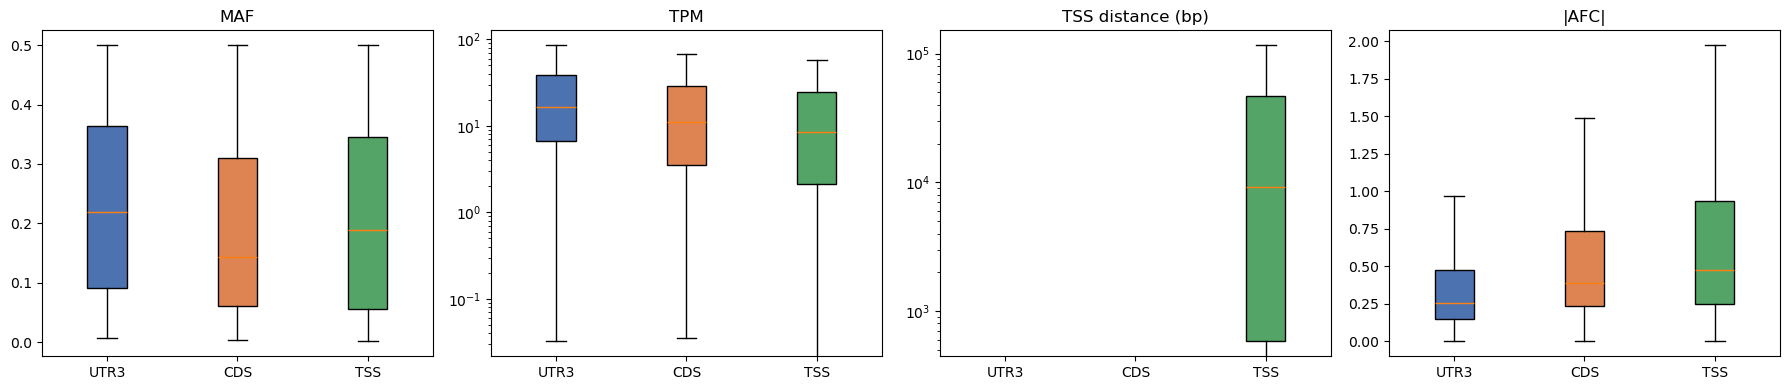

Pooled medians by region:
         maf    tpm     dist  effect    nlp
region                                     
UTR3   0.219 16.480      NaN   0.258 15.351
CDS    0.143 11.005      NaN   0.391 17.047
TSS    0.189  8.415 9161.000   0.478 14.915


In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, title, log in zip(
    axes, ["maf", "tpm", "dist", "effect"],
    ["MAF", "TPM", "TSS distance (bp)", "|AFC|"], [False, True, True, False]):
    data = [p.loc[p.region == r, col].abs().dropna().values for r in REGION_ORDER]
    bp = ax.boxplot(data, tick_labels=REGION_ORDER, showfliers=False, patch_artist=True)
    for patch, r in zip(bp["boxes"], REGION_ORDER):
        patch.set_facecolor(REGION_COLORS[r])
    ax.set_title(title)
    if log:
        ax.set_yscale("log")
plt.tight_layout()
plt.show()

print("Pooled medians by region:")
print(p.assign(effect=p.effect.abs())
       .groupby("region")[["maf", "tpm", "dist", "effect", "nlp"]]
       .median().reindex(REGION_ORDER).to_string(float_format="{:.3f}".format))

## QC 9: MAD outlier heatmap

Robust z-score per tissue × metric, signed so that positive is the suspicious
direction. Cells above z = 2 are boxed. Effect size is flagged in either tail —
unusually large and unusually small are both worth a look.

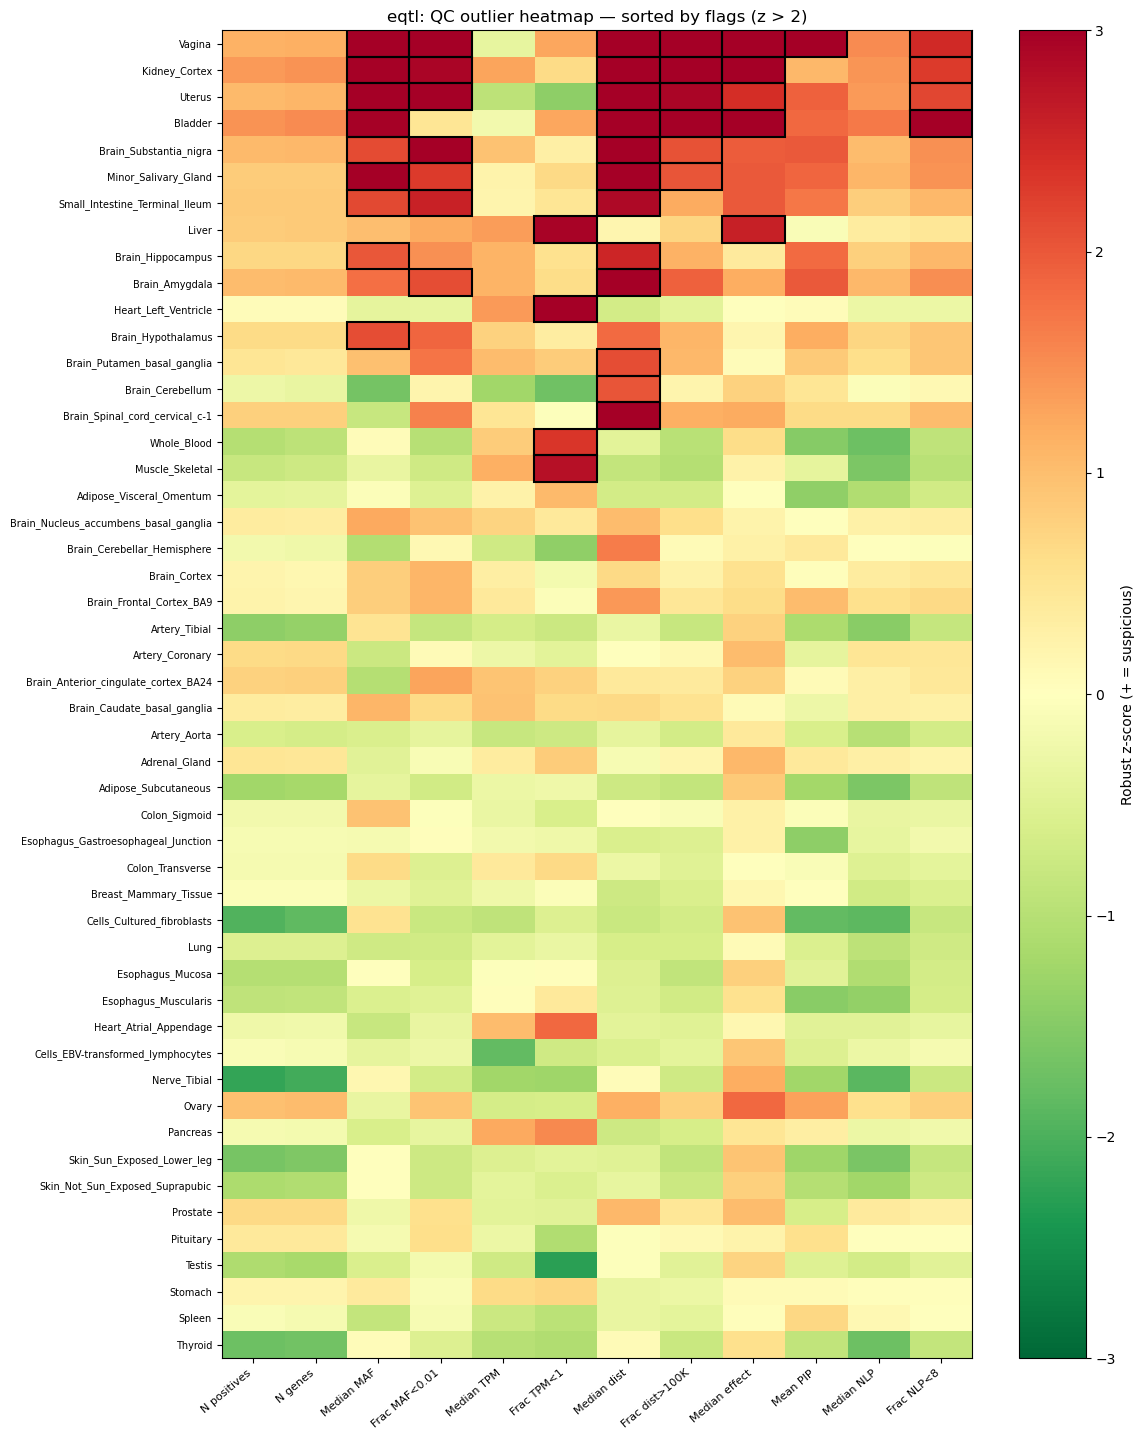

eqtl: tissues with ≥2 flags
                                n_flags
tissue                                 
Vagina                                7
Kidney_Cortex                         6
Uterus                                6
Bladder                               5
Brain_Substantia_nigra                4
Minor_Salivary_Gland                  4
Small_Intestine_Terminal_Ileum        3
Liver                                 2
Brain_Hippocampus                     2
Brain_Amygdala                        2 



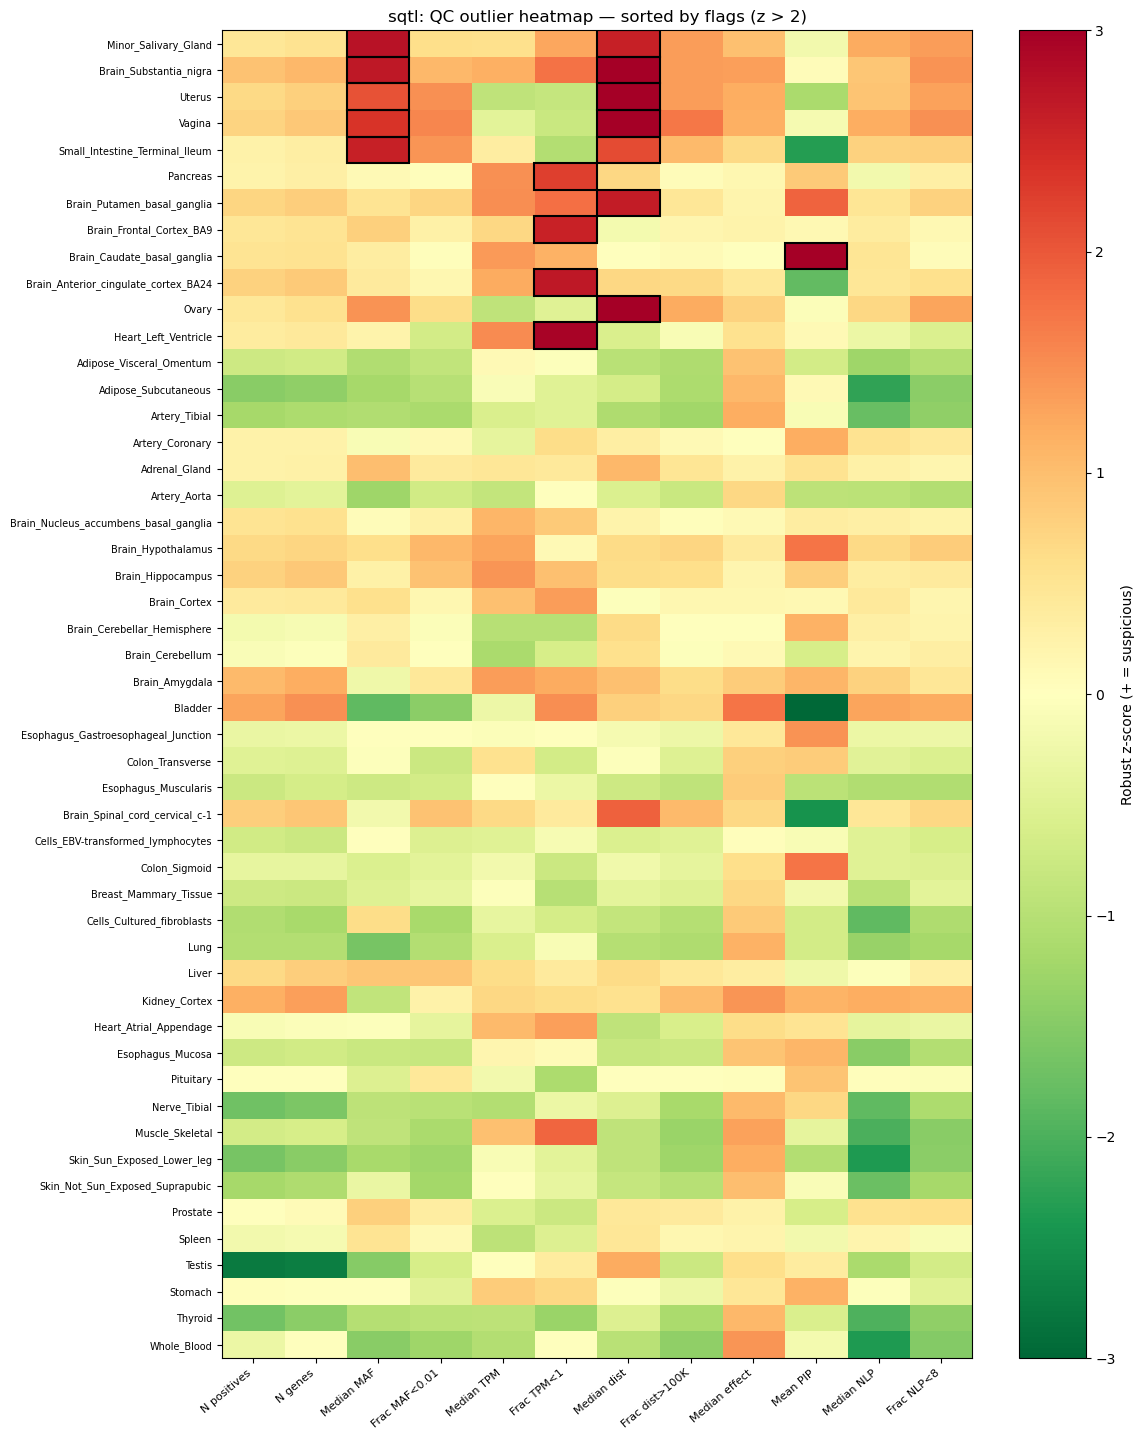

sqtl: tissues with ≥2 flags
                                n_flags
tissue                                 
Minor_Salivary_Gland                  2
Brain_Substantia_nigra                2
Uterus                                2
Vagina                                2
Small_Intestine_Terminal_Ileum        2 



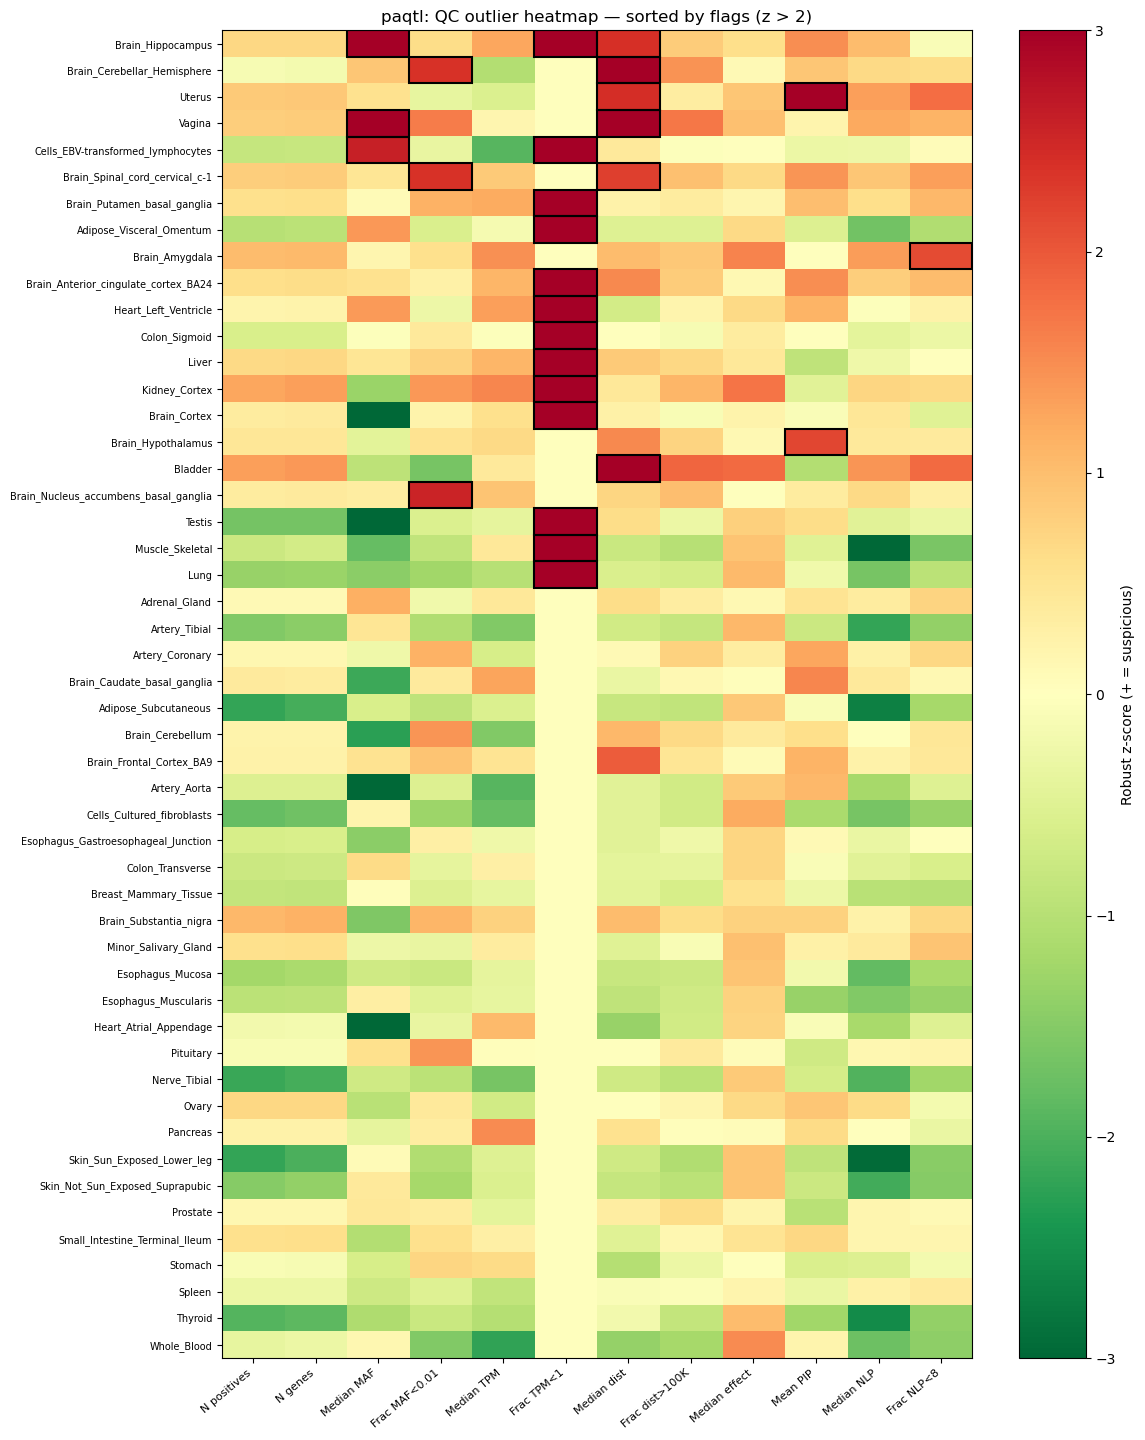

paqtl: tissues with ≥2 flags
                                   n_flags
tissue                                    
Brain_Hippocampus                        3
Brain_Cerebellar_Hemisphere              2
Uterus                                   2
Vagina                                   2
Cells_EBV-transformed_lymphocytes        2
Brain_Spinal_cord_cervical_c-1           2 



In [14]:
QC_METRICS = [
    ("n_pos",             "low",  "N positives"),
    ("n_genes",           "low",  "N genes"),
    ("median_maf",        "low",  "Median MAF"),
    ("frac_maf_rare",     "high", f"Frac MAF<{MAF_RARE:g}"),
    ("median_tpm",        "low",  "Median TPM"),
    ("frac_tpm_low",      "high", f"Frac TPM<{TPM_LOW:g}"),
    ("median_dist",       "high", "Median dist"),
    ("frac_dist_far",     "high", f"Frac dist>{DIST_FAR // 1000}K"),
    ("median_effect_abs", "both", "Median effect"),
    ("mean_pip",          "low",  "Mean PIP"),
    ("median_nlp",        "low",  "Median NLP"),
    ("frac_nlp_weak",     "high", f"Frac NLP<{NLP_WEAK:g}"),
]

zs = {}
for m in MODS:
    zs[m] = qc_lib.mad_heatmap(stats[m], QC_METRICS,
                               f"{m}: QC outlier heatmap — sorted by flags (z > 2)")
    print(f"{m}: tissues with ≥2 flags")
    print(zs[m][zs[m].n_flags >= 2][["n_flags"]].to_string(), "\n")

## QC 10: KS tests — each tissue against the rest

Two-sample KS on MAF, TPM and feature distance, Bonferroni-corrected within modality.

In [15]:
kss = {}
for m in MODS:
    kss[m], bonf = qc_lib.ks_table(pos[m], ["maf", "tpm", "dist"])
    print(f"=== {m}   Bonferroni threshold {bonf:.2e}")
    print(kss[m][["ks_maf", "p_maf", "ks_tpm", "p_tpm", "ks_dist", "p_dist", "n_sig"]]
          .head(10).to_string(float_format="{:.4f}".format), "\n")

=== eqtl   Bonferroni threshold 3.33e-04
                        ks_maf  p_maf  ks_tpm  p_tpm  ks_dist  p_dist  n_sig
tissue                                                                      
Bladder                 0.1153 0.0741  0.0942 0.2189   0.3902  0.0000      1
Kidney_Cortex           0.1090 0.0304  0.1945 0.0000   0.3006  0.0000      2
Vagina                  0.2165 0.0000  0.0585 0.1933   0.2899  0.0000      2
Uterus                  0.1446 0.0000  0.0936 0.0019   0.2417  0.0000      2
Heart_Left_Ventricle    0.0214 0.6950  0.2152 0.0000   0.0527  0.0089      1
Liver                   0.0442 0.2267  0.1734 0.0000   0.0727  0.0102      1
Brain_Amygdala          0.0881 0.0029  0.1656 0.0000   0.1724  0.0000      2
Pancreas                0.0287 0.2648  0.1713 0.0000   0.0583  0.0013      1
Brain_Substantia_nigra  0.1210 0.0000  0.1322 0.0000   0.1712  0.0000      3
Minor_Salivary_Gland    0.1137 0.0000  0.0531 0.0868   0.1700  0.0000      2 



=== sqtl   Bonferroni threshold 3.33e-04
                                      ks_maf  p_maf  ks_tpm  p_tpm  ks_dist  p_dist  n_sig
tissue                                                                                    
Pancreas                              0.0506 0.0184  0.2964 0.0000   0.0532  0.0112      1
Heart_Left_Ventricle                  0.0327 0.3439  0.2494 0.0000   0.0458  0.0647      1
Brain_Putamen_basal_ganglia           0.0691 0.0073  0.2418 0.0000   0.1160  0.0000      2
Brain_Hippocampus                     0.0747 0.0045  0.2329 0.0000   0.0959  0.0001      2
Brain_Amygdala                        0.0748 0.0363  0.2286 0.0000   0.1069  0.0006      1
Brain_Caudate_basal_ganglia           0.0550 0.0243  0.2267 0.0000   0.0566  0.0186      1
Brain_Hypothalamus                    0.0901 0.0001  0.1970 0.0000   0.1052  0.0000      3
Brain_Anterior_cingulate_cortex_BA24  0.0629 0.0251  0.1908 0.0000   0.1011  0.0000      2
Vagina                                0.1437 0.00

=== paqtl   Bonferroni threshold 3.33e-04
                                      ks_maf  p_maf  ks_tpm  p_tpm  ks_dist  p_dist  n_sig
tissue                                                                                    
Kidney_Cortex                         0.0715 0.8868  0.3426 0.0000   0.1469  0.1244      1
Pancreas                              0.0346 0.9462  0.2913 0.0000   0.0520  0.5716      1
Brain_Amygdala                        0.0785 0.5491  0.2793 0.0000   0.1204  0.1042      1
Brain_Putamen_basal_ganglia           0.0438 0.8905  0.2502 0.0000   0.0759  0.2733      1
Bladder                               0.1430 0.2165  0.1557 0.1445   0.2402  0.0040      0
Heart_Left_Ventricle                  0.0656 0.2723  0.2385 0.0000   0.0502  0.6016      1
Brain_Hippocampus                     0.1140 0.0365  0.2341 0.0000   0.1244  0.0170      1
Brain_Caudate_basal_ganglia           0.0400 0.8942  0.2316 0.0000   0.0435  0.8295      1
Brain_Anterior_cingulate_cortex_BA24  0.0549 0.6

## QC 11: tissues ranked by combined QC evidence

In [16]:
for m in MODS:
    s = stats[m][["n_pos", "median_maf", "median_tpm", "median_dist",
                  "median_effect_abs", "mean_pip"]].copy()
    s["mad_flags"] = zs[m].n_flags
    s["ks_sig"] = kss[m].n_sig
    s["total_flags"] = s.mad_flags + s.ks_sig
    print(f"=== {m}: ranked by MAD outlier flags + significant KS tests")
    print(s.sort_values("total_flags", ascending=False)
           .head(12).to_string(float_format="{:.3f}".format), "\n")

=== eqtl: ranked by MAD outlier flags + significant KS tests
                                n_pos  median_maf  median_tpm  median_dist  median_effect_abs  mean_pip  mad_flags  ks_sig  total_flags
tissue                                                                                                                                 
Vagina                            337       0.106      10.444    54296.500              0.899     0.977          7       2            9
Kidney_Cortex                     174       0.143       4.315    42383.000              0.973     0.980          6       2            8
Uterus                            395       0.141      12.584    38721.000              0.749     0.979          6       2            8
Brain_Substantia_nigra            401       0.156       5.536    21422.500              0.696     0.979          4       3            7
Bladder                           121       0.143       9.865   152720.000              0.843     0.979          5       1 

# Part 2: the matching

Part 1 asks whether the positives look sane. This part asks whether each negative is
a credible control for the positive it was paired with — a different question, and one
the marginal distributions alone cannot answer.

## QC 12: match rate

A positive goes unmatched when its allele bucket — `(region, ref, alt)` for eQTL,
`(ref, alt)` for sQTL and apaQTL — is empty or already exhausted.

In [17]:
for m in MODS:
    p = pos[m].copy()
    matched = pd.MultiIndex.from_arrays([match[m].tissue, match[m].pos_variant])
    p["matched"] = pd.MultiIndex.from_arrays([p.tissue, p.variant_id]).isin(matched)
    print(f"=== {m}: {len(p):,} tissue-level positives, {p.matched.mean():.2%} matched")
    if p.region.notna().any():
        g = p.groupby("region").matched.agg(["size", "sum", "mean"])
        g.columns = ["positives", "matched", "rate"]
        print(g.to_string())
    s = p.groupby("tissue").matched.mean()
    print("all tissues fully matched\n" if s.min() == 1 else
          f"worst tissues: {s.nsmallest(5).round(3).to_dict()}\n")

=== eqtl: 58,122 tissue-level positives, 100.00% matched
        positives  matched  rate
region                          
CDS          3989     3989   1.0
TSS         51121    51121   1.0
UTR3         3012     3012   1.0
all tissues fully matched



=== sqtl: 58,517 tissue-level positives, 100.00% matched
all tissues fully matched



=== paqtl: 14,823 tissue-level positives, 100.00% matched
all tissues fully matched



## QC 13: positive vs negative marginals

The covariates the matching score controls for. Positives and matched negatives
should overlap; residual separation is signal the model could exploit for the wrong
reason.

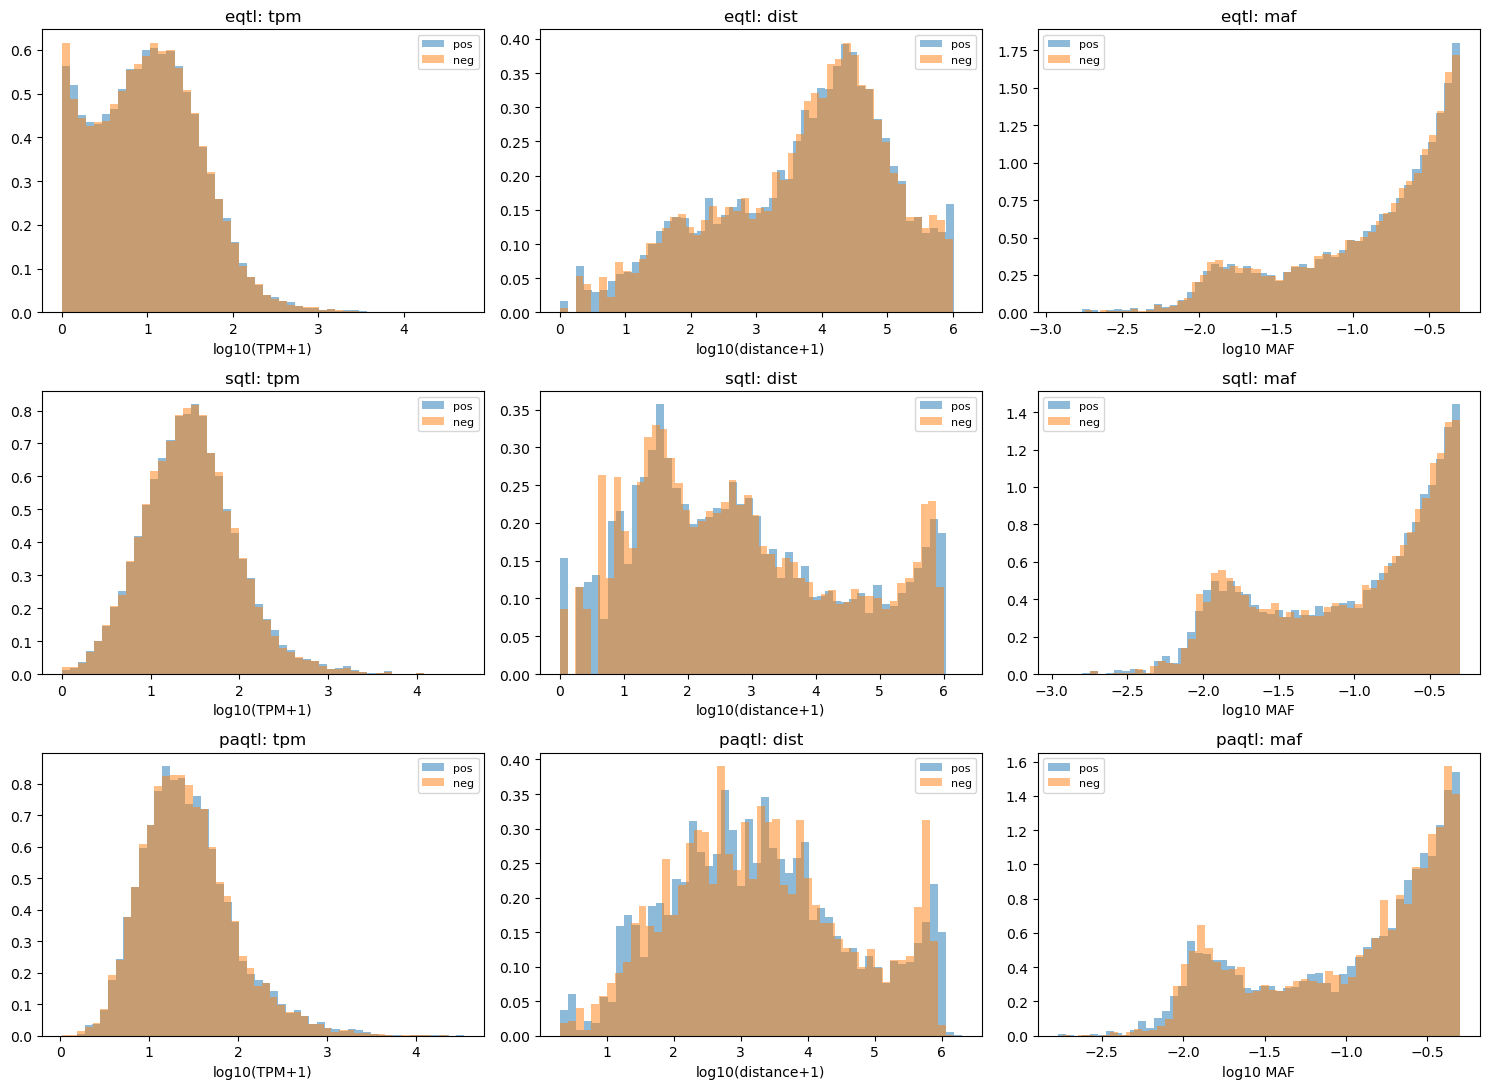

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for row, m in enumerate(MODS):
    d = sets[m]
    for col, (var, xf, xlabel) in enumerate([
        ("tpm", lambda x: np.log10(x + 1), "log10(TPM+1)"),
        ("dist", lambda x: np.log10(x + 1), "log10(distance+1)"),
        ("maf", np.log10, "log10 MAF"),
    ]):
        ax = axes[row, col]
        for label in ("pos", "neg"):
            v = d.loc[d.label == label, var].dropna()
            ax.hist(xf(v[v > 0] if var == "maf" else v), bins=50,
                    alpha=0.5, density=True, label=label)
        ax.set_xlabel(xlabel)
        ax.set_title(f"{m}: {var}")
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## QC 14: paired covariate agreement

QC 13 compares the two *distributions*; this compares the two *members of each pair*.
The marginals can overlap perfectly while the assignment is scrambled, and only the
scatter reveals that.

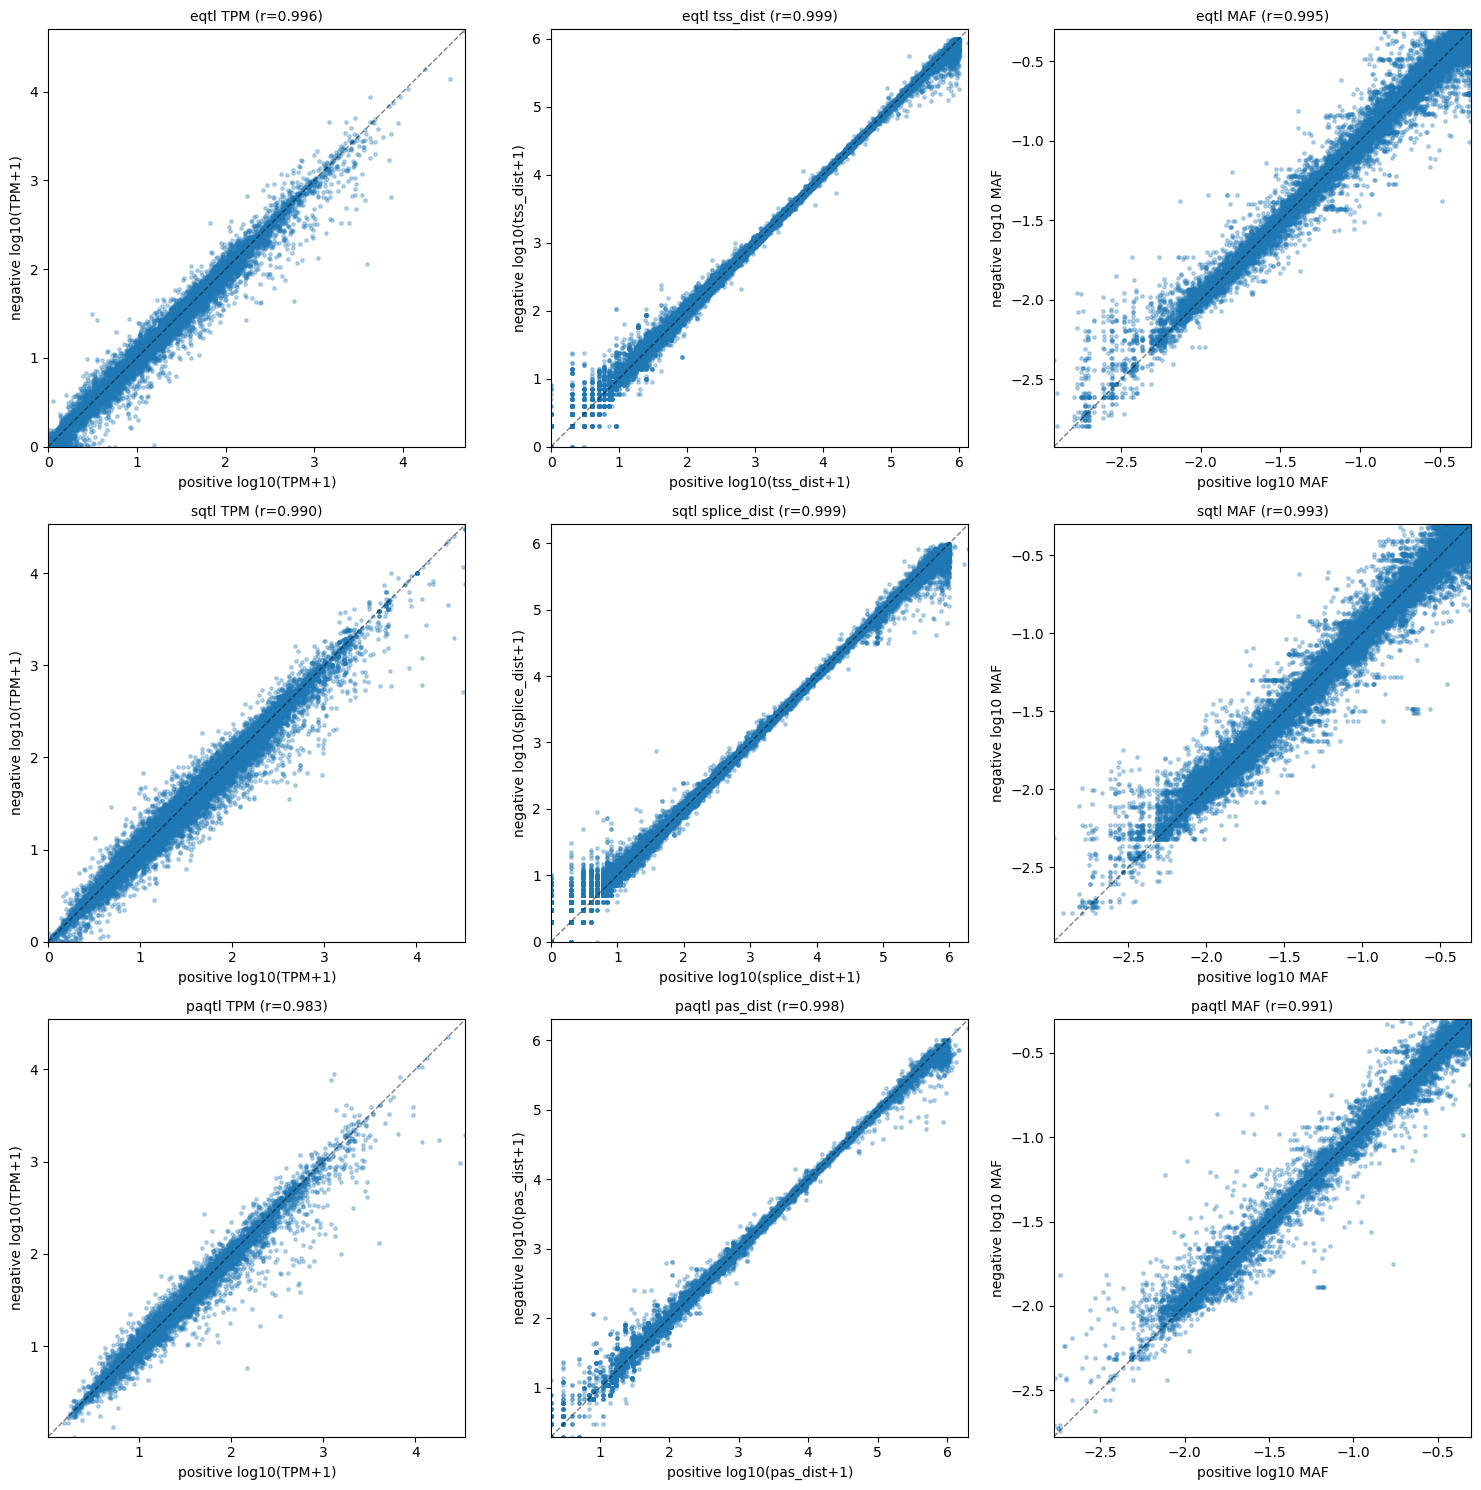

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for row, m in enumerate(MODS):
    mm = match[m]
    d = qc_lib.DIST_COL[m]
    panels = [
        ("TPM", lambda g, s: np.log10(g[f"{s}_tpm"] + 1), "log10(TPM+1)"),
        (d, lambda g, s: np.log10(g[f"{s}_{d}"] + 1), f"log10({d}+1)"),
        ("MAF", lambda g, s: np.log10(g[f"{s}_maf"].clip(lower=1e-3)), "log10 MAF"),
    ]
    for col, (name, xf, label) in enumerate(panels):
        qc_lib.paired_scatter(axes[row, col], xf(mm, "pos"), xf(mm, "neg"),
                              label, f"{m} {name}")
plt.tight_layout()
plt.show()

## QC 15: pairing summary

`same gene` should be near zero — a negative drawn from the positive's own gene is
not an independent control. The eQTL breakdown by region shows where the negative
pool is thin.

In [20]:
tbl = pd.DataFrame({m: qc_lib.pair_stats(match[m], qc_lib.DIST_COL[m]) for m in MODS})
print(tbl.to_string(float_format=lambda v: f"{v:.4f}"))

mm = match["eqtl"]
print("\n=== eqtl by region")
print(pd.DataFrame({r: qc_lib.pair_stats(g, "tss_dist")
                    for r, g in mm.groupby("region")})
      .to_string(float_format=lambda v: f"{v:.4f}"))

                      eqtl       sqtl      paqtl
pairs           58122.0000 58517.0000 14823.0000
r log10(TPM+1)      0.9956     0.9903     0.9834
r log10(dist+1)     0.9990     0.9987     0.9977
r log10(MAF)        0.9953     0.9934     0.9908
same gene           0.0121     0.0135     0.0130
median score        0.0867     0.1707     0.2126

=== eqtl by region
                      CDS        TSS      UTR3
pairs           3989.0000 51121.0000 3012.0000
r log10(TPM+1)     0.9963     0.9954    0.9968
r log10(dist+1)       NaN     0.9990       NaN
r log10(MAF)       0.9959     0.9953    0.9956
same gene          0.0058     0.0121    0.0203
median score       0.0845     0.0885    0.0685


## QC 16: match score

`score = |Δlog1p(TPM)| + |Δlog1p(dist)| + |Δlog(MAF)|`, lower is tighter; the
distance term is dropped for eQTL UTR3 and CDS, where compartment overlap already
controls for context.

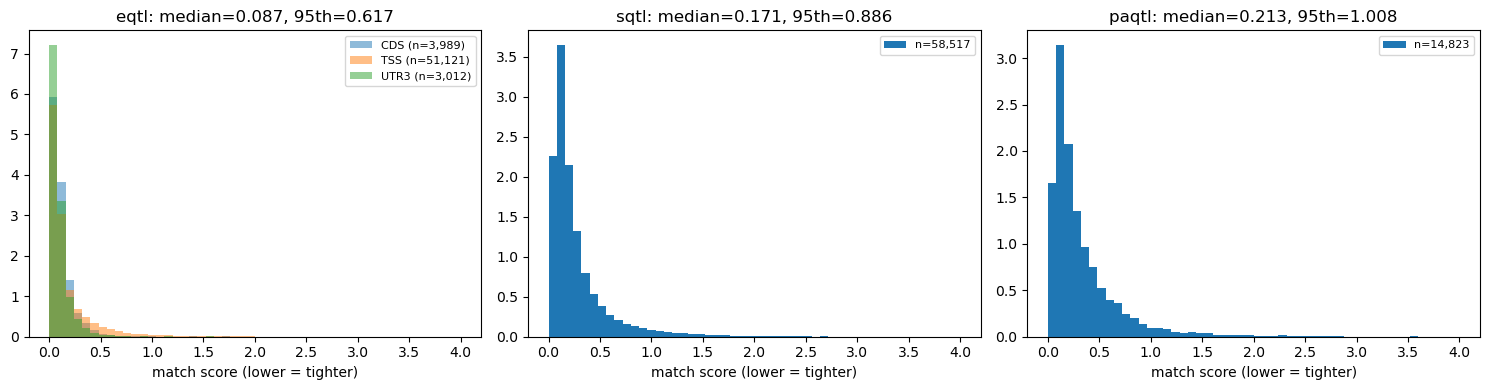

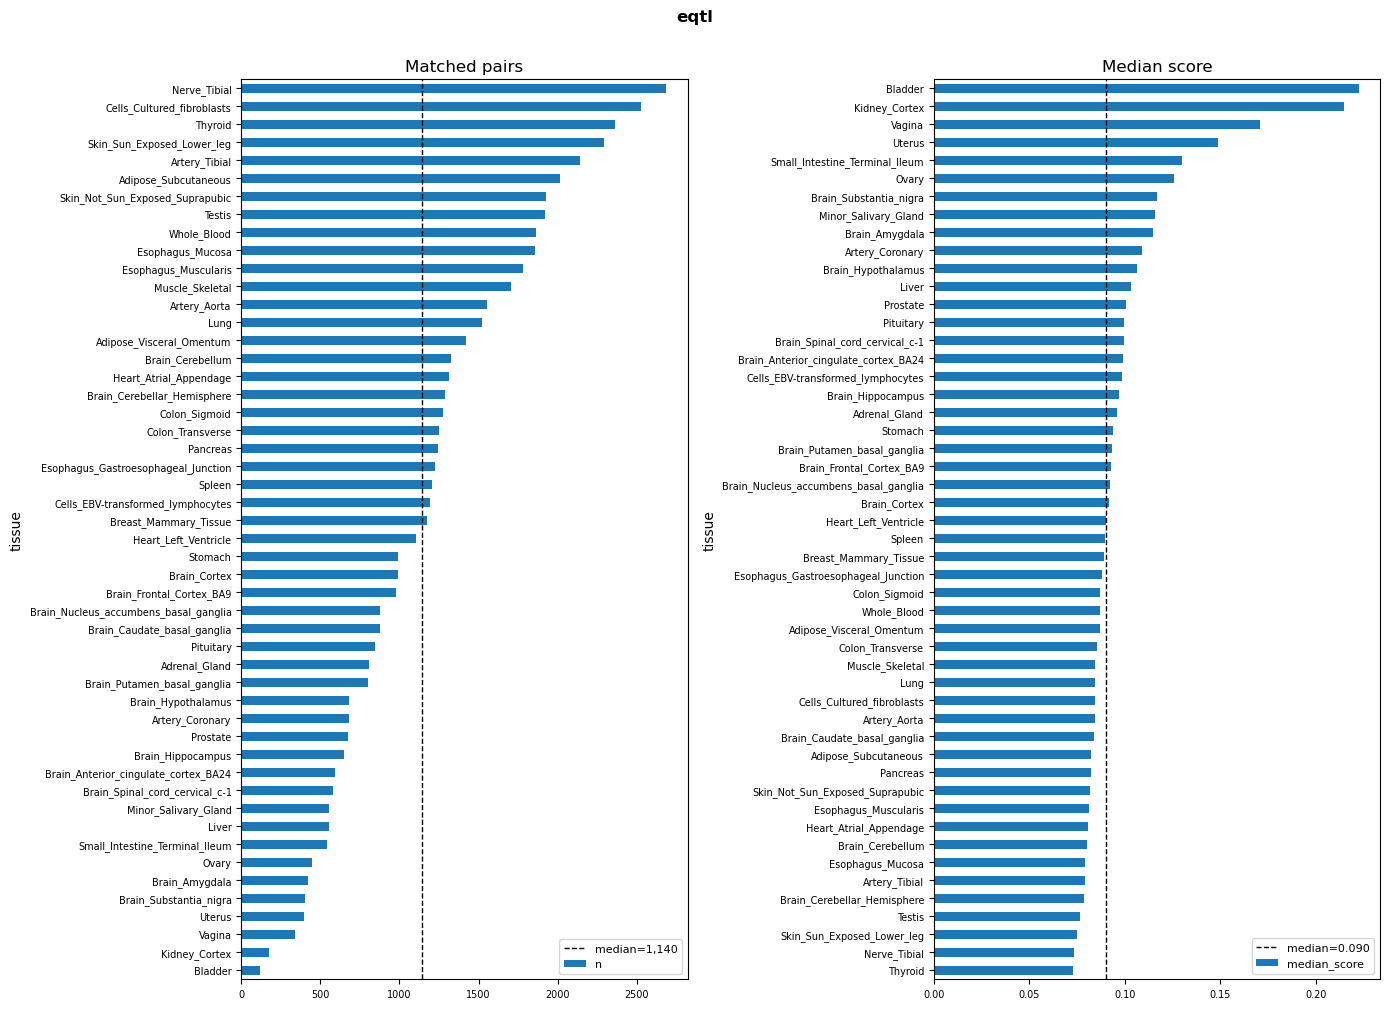

eqtl: corr(n_matches, median_score) = -0.682


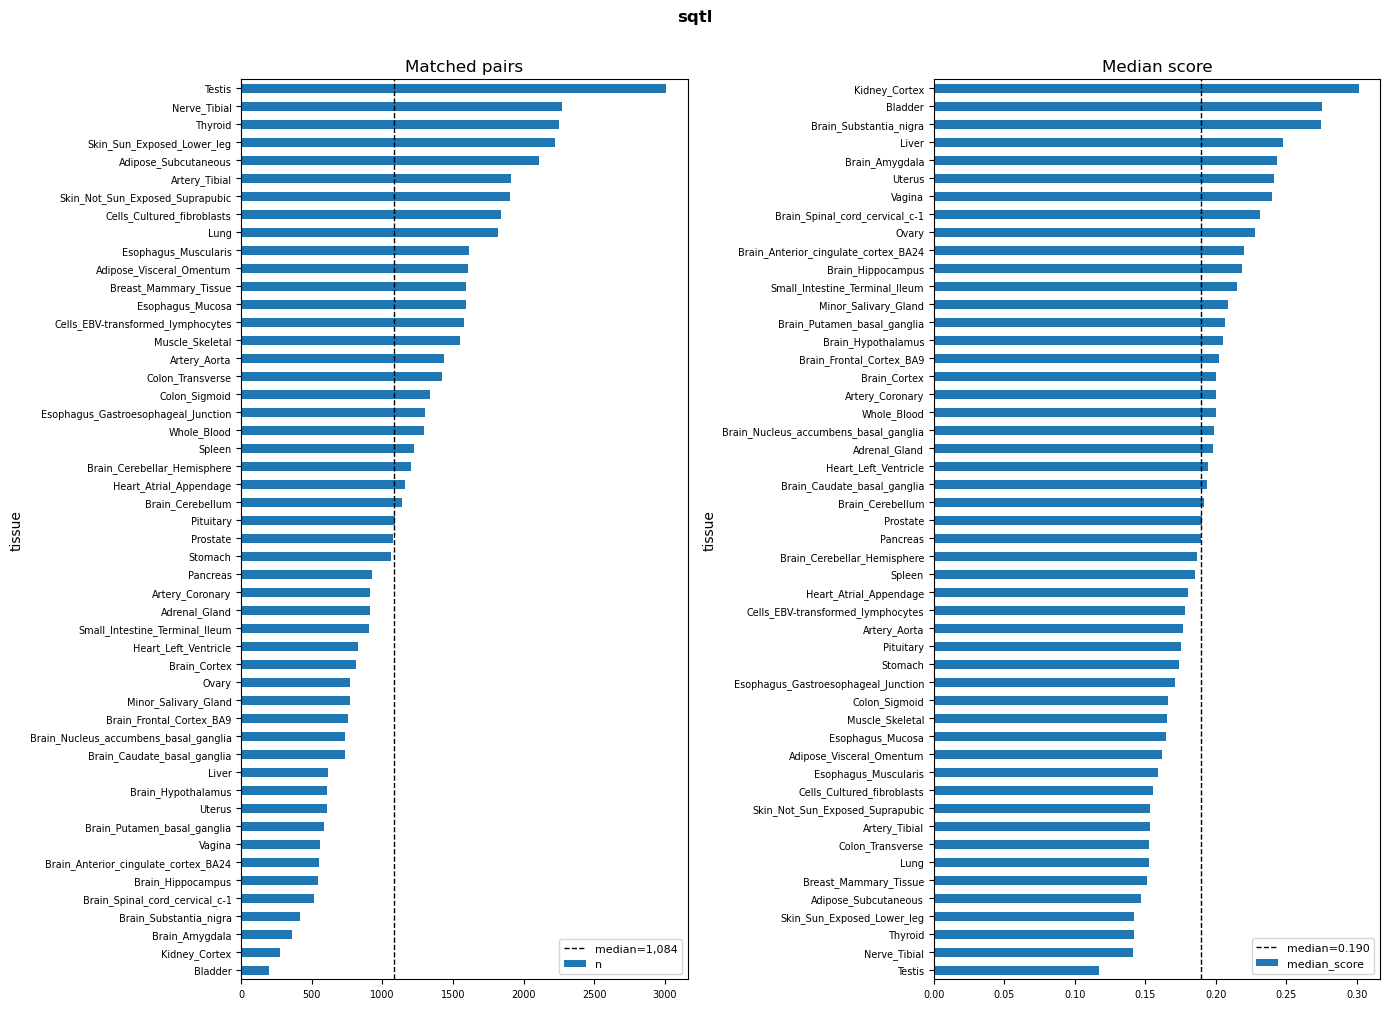

sqtl: corr(n_matches, median_score) = -0.897


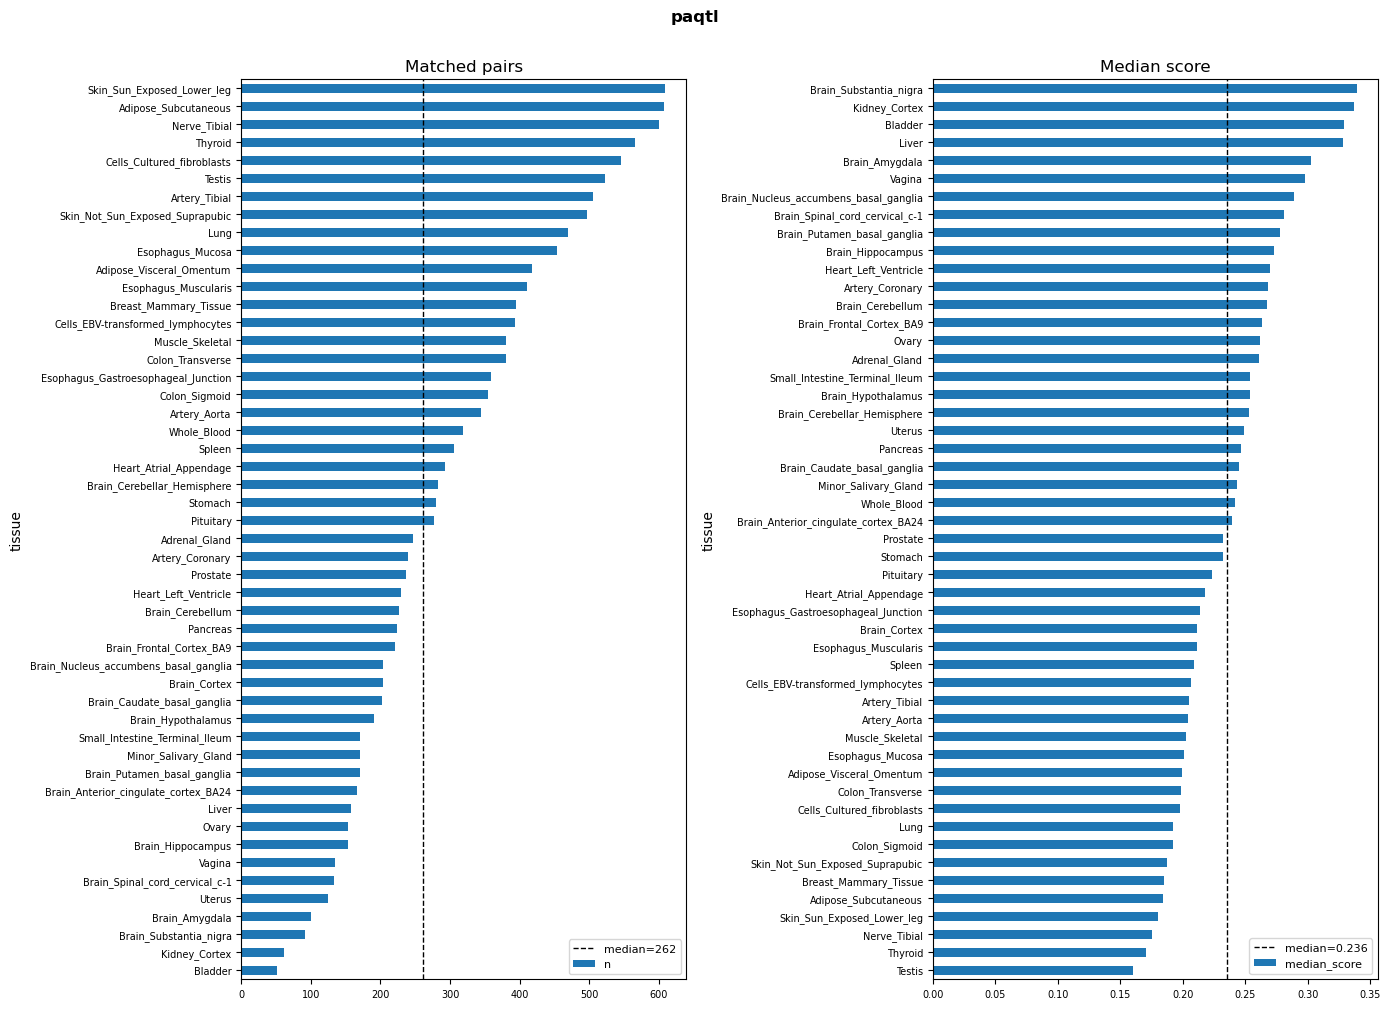

paqtl: corr(n_matches, median_score) = -0.873


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, MODS):
    mm = match[m]
    if "region" in mm.columns:
        for region, grp in mm.groupby("region"):
            ax.hist(grp.score, bins=50, range=(0, 4), alpha=0.5, density=True,
                    label=f"{region} (n={len(grp):,})")
    else:
        ax.hist(mm.score, bins=50, range=(0, 4), density=True, label=f"n={len(mm):,}")
    ax.set_xlabel("match score (lower = tighter)")
    ax.set_title(f"{m}: median={mm.score.median():.3f}, "
                 f"95th={mm.score.quantile(0.95):.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for m in MODS:
    ts = match[m].groupby("tissue").agg(n=("score", "size"),
                                        median_score=("score", "median"))
    qc_lib.barh_panels(ts.sort_values("n"),
                       [("n", "Matched pairs"), ("median_score", "Median score")],
                       suptitle=m)
    print(f"{m}: corr(n_matches, median_score) = "
          f"{np.corrcoef(ts.n, ts.median_score)[0, 1]:.3f}")

## QC 17: worst-scoring pairs

The tail of the score distribution, inspected directly. These are the pairs whose
negative is least like its positive; if they are numerous or systematic, the bucket
is too thin.

In [22]:
for m in MODS:
    mm = match[m]
    d = qc_lib.DIST_COL[m]
    worst = mm.nlargest(3, "score").copy()
    worst["d_log1p_tpm"] = (np.log1p(worst.pos_tpm) - np.log1p(worst.neg_tpm)).abs()
    worst["d_log1p_dist"] = (np.log1p(worst[f"pos_{d}"]) - np.log1p(worst[f"neg_{d}"])).abs()
    worst["d_log_maf"] = (np.log(worst.pos_maf.clip(1e-4))
                          - np.log(worst.neg_maf.clip(1e-4))).abs()
    cols = ["tissue", "pos_variant", "neg_variant", "pos_gene", "neg_gene", "score",
            f"pos_{d}", f"neg_{d}", "d_log1p_dist", "pos_tpm", "neg_tpm", "d_log1p_tpm",
            "pos_maf", "neg_maf", "d_log_maf"]
    print(f"=== {m}: 3 worst-scoring pairs of {len(mm):,}")
    print(worst[cols].T.to_string(), "\n")

=== eqtl: 3 worst-scoring pairs of 58,122
                               18907                   6662                             45913
tissue        Brain_Substantia_nigra           Artery_Tibial  Skin_Not_Sun_Exposed_Suprapubic
pos_variant   chr17_44346806_A_G_b38  chr11_85686194_A_T_b38            chr6_33272092_C_T_b38
neg_variant    chr4_57669467_A_G_b38  chr17_63911254_A_T_b38            chr6_73523898_C_T_b38
pos_gene             ENSG00000131095         ENSG00000179071                  ENSG00000231500
neg_gene             ENSG00000163453         ENSG00000204414                  ENSG00000156508
score                       3.688217                3.037085                         3.026996
pos_tss_dist                568679.0                     0.0                             18.0
neg_tss_dist                559082.0                     4.0                             61.0
d_log1p_dist                 0.01702                1.609438                         1.182695
pos_tpm           